# 🔬 Wind CFD Dataset — Deep EDA Notebook
### OpenFOAM RANS Dataset Analysis for GNN Surrogate Model Readiness
---
**Goal:** Sirf data analysis — koi ML training nahi. Ye notebook batayega:
- Dataset structure, quality, angle diversity
- Pressure & velocity distributions
- Boundary condition consistency  
- Spatial representation
- ML training ke liye kya theek hai, kya fix karna padega

**Based on:** 39 OpenFOAM RANS cases, Mohali/Dublin/Mombasa locations


In [1]:
import os, re, json, math
from pathlib import Path
from typing import List, Dict, Optional, Tuple
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import warnings; warnings.filterwarnings('ignore')

# scipy
from scipy import stats
from scipy.spatial import cKDTree

# Optional: seaborn for nicer plots
try:
    import seaborn as sns
    sns.set_style('whitegrid')
    HAS_SNS = True
except ImportError:
    HAS_SNS = False

print("Imports OK")
print(f"NumPy: {np.__version__}")


Imports OK
NumPy: 2.0.2


In [2]:
# ─── CHANGE THIS PATH to your dataset ────────────────────────────────────────
DATASET_ROOT = Path('/kaggle/input/datasets/kunal320/dataset/mohali_dataset')
OUTPUT_DIR   = Path('/kaggle/working/eda_output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Physics constants
RHO   = 1.225     # air density [kg/m³]
NU    = 1.5e-5    # kinematic viscosity [m²/s]
P_REF = 101325.0  # atmospheric reference [Pa]

print(f"Dataset root: {DATASET_ROOT}")
print(f"Output dir:   {OUTPUT_DIR}")


Dataset root: /kaggle/input/datasets/kunal320/dataset/mohali_dataset
Output dir:   /kaggle/working/eda_output


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# OpenFOAM Parsers
# ─────────────────────────────────────────────────────────────────────────────

def _foam_body(text):
    text = text.replace('\r', '')
    sep  = text.find('// *')
    after = text[sep:] if sep != -1 else text
    m = re.search(r'(\d+)\s*\n\(', after)
    if not m: raise ValueError('Cannot find list count')
    count = int(m.group(1))
    start = (sep if sep != -1 else 0) + m.end()
    end   = text.find('\n)\n', start)
    if end == -1: end = text.find('\n)', start)
    return text[start:end], count

def _count_cells_from_owner(owner_file):
    text = owner_file.read_text(errors='ignore')
    m = re.search(r'nCells:(\d+)', text)
    if m: return int(m.group(1))
    body, _ = _foam_body(text)
    arr = np.fromstring(body, sep='\n', dtype=np.int32)
    return int(arr.max()) + 1

def parse_foam_scalar(filepath):
    text = filepath.read_text(errors='ignore').replace('\r', '')
    m = re.search(r'internalField\s+nonuniform\s+List<scalar>\s+(\d+)\s*\(', text)
    if m:
        n = int(m.group(1)); start = m.end()
        end = text.find('\n)\n', start)
        if end == -1: end = text.find('\n)', start)
        return np.fromstring(text[start:end], sep='\n', dtype=np.float32)[:n]
    m2 = re.search(r'internalField\s+uniform\s+([\d.e+\-]+)', text)
    if m2:
        owner_file = filepath.parent.parent / 'constant' / 'polyMesh' / 'owner'
        n = _count_cells_from_owner(owner_file)
        return np.full(n, float(m2.group(1)), dtype=np.float32)
    raise ValueError(f'Cannot parse scalar: {filepath}')

def parse_foam_vector(filepath):
    text = filepath.read_text(errors='ignore').replace('\r', '')
    m = re.search(r'internalField\s+nonuniform\s+List<vector>\s+(\d+)\s*\(', text)
    if m:
        n = int(m.group(1)); start = m.end()
        tuples = re.findall(r'\(([^)]+)\)', text[start:])[:n]
        return np.array([list(map(float, t.split())) for t in tuples], dtype=np.float32)
    m2 = re.search(r'internalField\s+uniform\s+\(([^)]+)\)', text)
    if m2:
        vec = np.array(list(map(float, m2.group(1).split())), dtype=np.float32)
        owner_file = filepath.parent.parent / 'constant' / 'polyMesh' / 'owner'
        n = _count_cells_from_owner(owner_file)
        return np.tile(vec, (n, 1))
    raise ValueError(f'Cannot parse vector: {filepath}')

def parse_foam_labellist(filepath, dtype=np.int32):
    text = filepath.read_text(errors='ignore')
    body, count = _foam_body(text)
    return np.fromstring(body, sep='\n', dtype=dtype)[:count]

def parse_foam_points(filepath):
    text = filepath.read_text(errors='ignore').replace('\r', '')
    body, count = _foam_body(text)
    tuples = re.findall(r'\(([^)]+)\)', body)[:count]
    return np.array([list(map(float, t.split())) for t in tuples], dtype=np.float32)

def parse_boundary_patches(mesh_dir):
    text = (mesh_dir / 'boundary').read_text(errors='ignore')
    patches = {}
    for m in re.finditer(
        r'(\w+)\s*\{[^}]*?type\s+(\w+);[^}]*?nFaces\s+(\d+);[^}]*?startFace\s+(\d+);',
        text, re.DOTALL
    ):
        patches[m.group(1)] = {'type':m.group(2), 'nFaces':int(m.group(3)), 'startFace':int(m.group(4))}
    return patches

def parse_inlet_velocity(case_dir):
    text = (case_dir / '0' / 'U').read_text(errors='ignore')
    m = re.search(r'Uinlet\s+\(([^)]+)\)', text)
    if m: return np.array(list(map(float, m.group(1).split())), dtype=np.float32)
    m2 = re.search(r'inlet.*?fixedValue.*?uniform\s+\(([^)]+)\)', text, re.DOTALL)
    if m2: return np.array(list(map(float, m2.group(1).split())), dtype=np.float32)
    raise ValueError(f'Cannot parse Uinlet')

def _find_converged_timestep(case_dir):
    candidates = []
    for d in case_dir.iterdir():
        if d.is_dir() and re.fullmatch(r'\d+', d.name) and int(d.name) > 0:
            candidates.append((int(d.name), d))
    if not candidates: return None
    return sorted(candidates, reverse=True)[0][1]

def compute_cell_centers(case_dir):
    mesh_dir = case_dir / 'constant' / 'polyMesh'
    points   = parse_foam_points(mesh_dir / 'points')
    faces_text = (mesh_dir / 'faces').read_text(errors='ignore').replace('\r', '')
    body_f, n_faces = _foam_body(faces_text)
    face_entries = re.findall(r'\d+\(([^)]+)\)', body_f)[:n_faces]
    face_centers = np.array([points[list(map(int, e.split()))].mean(axis=0) for e in face_entries], dtype=np.float32)
    owner     = parse_foam_labellist(mesh_dir / 'owner')
    neighbour = parse_foam_labellist(mesh_dir / 'neighbour')
    n_internal= len(neighbour)
    n_cells   = _count_cells_from_owner(mesh_dir / 'owner')
    cell_sum  = np.zeros((n_cells, 3), dtype=np.float64)
    cell_cnt  = np.zeros(n_cells, dtype=np.int32)
    n_fc = len(face_centers); safe_nf = min(n_fc, len(owner)); safe_ni = min(min(n_internal, n_fc), len(face_centers))
    np.add.at(cell_sum, owner[:safe_nf],     face_centers[:safe_nf]);    np.add.at(cell_cnt, owner[:safe_nf],     1)
    np.add.at(cell_sum, neighbour[:safe_ni], face_centers[:safe_ni]);    np.add.at(cell_cnt, neighbour[:safe_ni], 1)
    cell_centers = (cell_sum / np.maximum(cell_cnt[:, None], 1)).astype(np.float32)
    patches = parse_boundary_patches(mesh_dir)
    boundary_cells = {}
    for name, p in patches.items():
        s, nf = p['startFace'], p['nFaces']
        boundary_cells[name] = set(owner[s:s+nf].tolist())
    return cell_centers, boundary_cells, patches

print("Parsers defined ✓")


Parsers defined ✓


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1: Load All Cases
# ─────────────────────────────────────────────────────────────────────────────

def discover_cases(root):
    cases = []
    for owner_file in sorted(root.rglob('constant/polyMesh/owner')):
        case_dir = owner_file.parent.parent.parent
        if re.match(r'processor\d+$', case_dir.name): continue
        if (case_dir / '0').is_dir(): cases.append(case_dir)
    seen = set(); unique = []
    for c in cases:
        if c not in seen: seen.add(c); unique.append(c)
    return unique

def load_case_full(case_dir):
    try:
        ts_dir = _find_converged_timestep(case_dir)
        if ts_dir is None: return None
        p_file, u_file = ts_dir / 'p', ts_dir / 'U'
        if not (p_file.exists() and u_file.exists()): return None
        p_vals      = parse_foam_scalar(p_file)
        u_vals      = parse_foam_vector(u_file)
        u_inlet     = parse_inlet_velocity(case_dir)
        cell_centers, boundary_cells, patches = compute_cell_centers(case_dir)
        # Try turbulence fields
        k_vals = None; eps_vals = None; nut_vals = None
        for field_name, setter in [('k', lambda v: v), ('epsilon', lambda v: v), ('nut', lambda v: v)]:
            try:
                if (ts_dir / field_name).exists():
                    if field_name == 'k':    k_vals   = parse_foam_scalar(ts_dir / 'k')
                    elif field_name == 'epsilon': eps_vals = parse_foam_scalar(ts_dir / 'epsilon')
                    elif field_name == 'nut': nut_vals  = parse_foam_scalar(ts_dir / 'nut')
            except: pass
        n = min(len(p_vals), len(u_vals), len(cell_centers))
        # OBJ file (geometry)
        obj_file = case_dir / 'constant' / 'triSurface' / 'buildings.obj'
        obj_exists = obj_file.exists()
        return {
            'case_name':      case_dir.name,
            'location':       case_dir.parent.name,
            'case_path':      str(case_dir),
            'timestep':       int(ts_dir.name),
            'n_cells':        n,
            'cell_centers':   cell_centers[:n],
            'p_raw':          p_vals[:n],              # absolute Pa (raw from OpenFOAM)
            'p_gauge':        p_vals[:n] - P_REF,      # gauge Pa
            'U':              u_vals[:n],               # m/s [Ux, Uy, Uz]
            'Uinlet':         u_inlet,
            'boundary_cells': boundary_cells,
            'patches':        patches,
            'k':              k_vals[:n] if k_vals is not None else None,
            'epsilon':        eps_vals[:n] if eps_vals is not None else None,
            'nut':            nut_vals[:n] if nut_vals is not None else None,
            'obj_exists':     obj_exists,
        }
    except Exception as e:
        print(f'  [ERROR] {case_dir.name}: {e}')
        return None

print("Discovering cases...")
case_dirs = discover_cases(DATASET_ROOT)
print(f"Found {len(case_dirs)} cases")

print("\nLoading all cases (this may take a few minutes)...")
from tqdm import tqdm
cases = []
for cd in tqdm(case_dirs):
    r = load_case_full(cd)
    if r is not None: cases.append(r)

print(f"\n✅ Successfully loaded: {len(cases)} / {len(case_dirs)} cases")


Discovering cases...
Found 40 cases

Loading all cases (this may take a few minutes)...


100%|██████████| 40/40 [13:39<00:00, 20.48s/it]


✅ Successfully loaded: 38 / 40 cases


  SECTION 1: BASIC STRUCTURE

📊 Total cases loaded:       38
   Cell count range:          204,531 – 518,208
   Cell count mean:           304,596
   Cell count std:            84,820
   Are all mesh sizes same?   NO ❌ — 16 unique sizes

📍 Cases per location:
   dublin_Spring                    4 cases
   dublin_Summer                    4 cases
   dublin_Winter                    4 cases
   mohali_autumn                    5 cases
   mohali_spring                    5 cases
   mohali_summer                    4 cases
   mohali_winter                    4 cases
   mombasa_Summer                   4 cases
   mombasa_Winter                   4 cases

⏱️  Converged timestep distribution:
   t= 2000   →    4 cases
   t= 4000   →   34 cases

📐 OBJ geometry file present: 38/38 cases

🌊 Turbulence fields available:
   k (TKE):       38/38
   epsilon:       38/38
   nut:           38/38

🔍 NaN / Inf Check:
   ✅ No NaN or Inf in any case


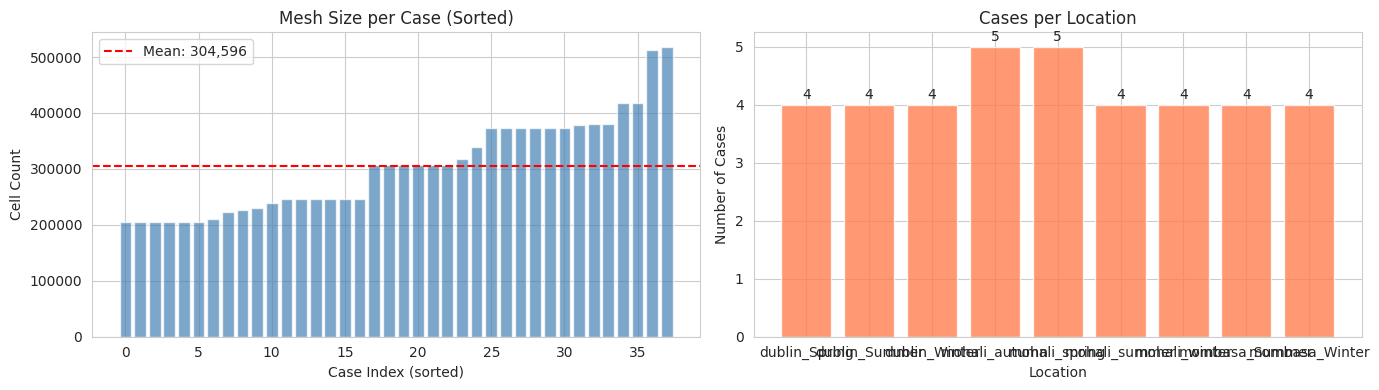


Saved: S1_basic_structure.png


In [5]:
# ═════════════════════════════════════════════════════════════════════════════
# SECTION 1: BASIC STRUCTURE ANALYSIS
# ═════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("  SECTION 1: BASIC STRUCTURE")
print("=" * 70)

# 1.1 Total samples, locations, mesh sizes
node_counts = [c['n_cells'] for c in cases]
loc_counts  = defaultdict(int)
for c in cases: loc_counts[c['location']] += 1

print(f"\n📊 Total cases loaded:       {len(cases)}")
print(f"   Cell count range:          {min(node_counts):,} – {max(node_counts):,}")
print(f"   Cell count mean:           {np.mean(node_counts):,.0f}")
print(f"   Cell count std:            {np.std(node_counts):,.0f}")
print(f"   Are all mesh sizes same?   {'YES ✅' if len(set(node_counts)) == 1 else f'NO ❌ — {len(set(node_counts))} unique sizes'}")

print(f"\n📍 Cases per location:")
for loc, cnt in sorted(loc_counts.items()):
    print(f"   {loc:<30} {cnt:>3} cases")

# 1.2 Timestep (convergence)
timesteps = [c['timestep'] for c in cases]
ts_counter = defaultdict(int)
for t in timesteps: ts_counter[t] += 1
print(f"\n⏱️  Converged timestep distribution:")
for ts, cnt in sorted(ts_counter.items()):
    print(f"   t={ts:>5}   →  {cnt:>3} cases")

# 1.3 OBJ file presence
obj_yes = sum(1 for c in cases if c['obj_exists'])
print(f"\n📐 OBJ geometry file present: {obj_yes}/{len(cases)} cases")

# 1.4 Turbulence fields
k_avail   = sum(1 for c in cases if c['k']   is not None)
eps_avail = sum(1 for c in cases if c['epsilon'] is not None)
nut_avail = sum(1 for c in cases if c['nut'] is not None)
print(f"\n🌊 Turbulence fields available:")
print(f"   k (TKE):       {k_avail}/{len(cases)}")
print(f"   epsilon:       {eps_avail}/{len(cases)}")
print(f"   nut:           {nut_avail}/{len(cases)}")

# 1.5 NaN / Inf check
print("\n🔍 NaN / Inf Check:")
nan_cases = []
for c in cases:
    has_nan = np.any(np.isnan(c['p_raw'])) or np.any(np.isnan(c['U']))
    has_inf = np.any(np.isinf(c['p_raw'])) or np.any(np.isinf(c['U']))
    if has_nan or has_inf:
        nan_cases.append(c['case_name'])
        print(f"   ⚠️  {c['case_name']}: NaN={has_nan}, Inf={has_inf}")
if not nan_cases:
    print("   ✅ No NaN or Inf in any case")

# 1.6 Cell count histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(len(cases)), sorted(node_counts), color='steelblue', alpha=0.7)
axes[0].axhline(np.mean(node_counts), color='red', ls='--', label=f'Mean: {np.mean(node_counts):,.0f}')
axes[0].set_xlabel('Case Index (sorted)'); axes[0].set_ylabel('Cell Count')
axes[0].set_title('Mesh Size per Case (Sorted)'); axes[0].legend()

loc_names = sorted(loc_counts.keys()); loc_vals = [loc_counts[l] for l in loc_names]
axes[1].bar(loc_names, loc_vals, color='coral', alpha=0.8)
axes[1].set_xlabel('Location'); axes[1].set_ylabel('Number of Cases')
axes[1].set_title('Cases per Location')
for i, v in enumerate(loc_vals): axes[1].text(i, v+0.1, str(v), ha='center')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'S1_basic_structure.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nSaved: S1_basic_structure.png")


  SECTION 2: TARGET VARIABLE DISTRIBUTIONS

📊 RAW OpenFOAM Pressure (absolute, Pa):
  p_abs [Pa]    min=101106.0000  max=101390.0000  mean=101324.9766  std=   11.7223  p5=101309.0000  p95=101352.0000

📊 GAUGE Pressure (p - P_REF, Pa):
  p_gauge [Pa]  min= -219.0000  max=   65.0000  mean=   -0.5637  std=   11.7098  p5=  -16.0000  p95=   27.0000

📊 Velocity Components [m/s]:
  Ux [m/s]      min=  -20.1839  max=   15.6448  mean=   -0.3995  std=    1.8683  p5=   -4.2581  p95=    2.3943
  Uy [m/s]      min=  -19.7548  max=   18.6221  mean=    0.4512  std=    1.4793  p5=   -2.1536  p95=    2.8140
  Uz [m/s]      min=   -7.2203  max=   10.4623  mean=    0.0735  std=    0.4981  p5=   -0.5514  p95=    0.9374
  |U| [m/s]     min=    0.0000  max=   20.1860  mean=    2.0095  std=    1.5025  p5=    0.2806  p95=    4.9922

⚖️  Scale Comparison (important for ML loss weighting):
   p_gauge [Pa]          std = 11.7098
   Ux [m/s]              std = 1.8683
   Uy [m/s]              std = 1.4793
   Uz [m

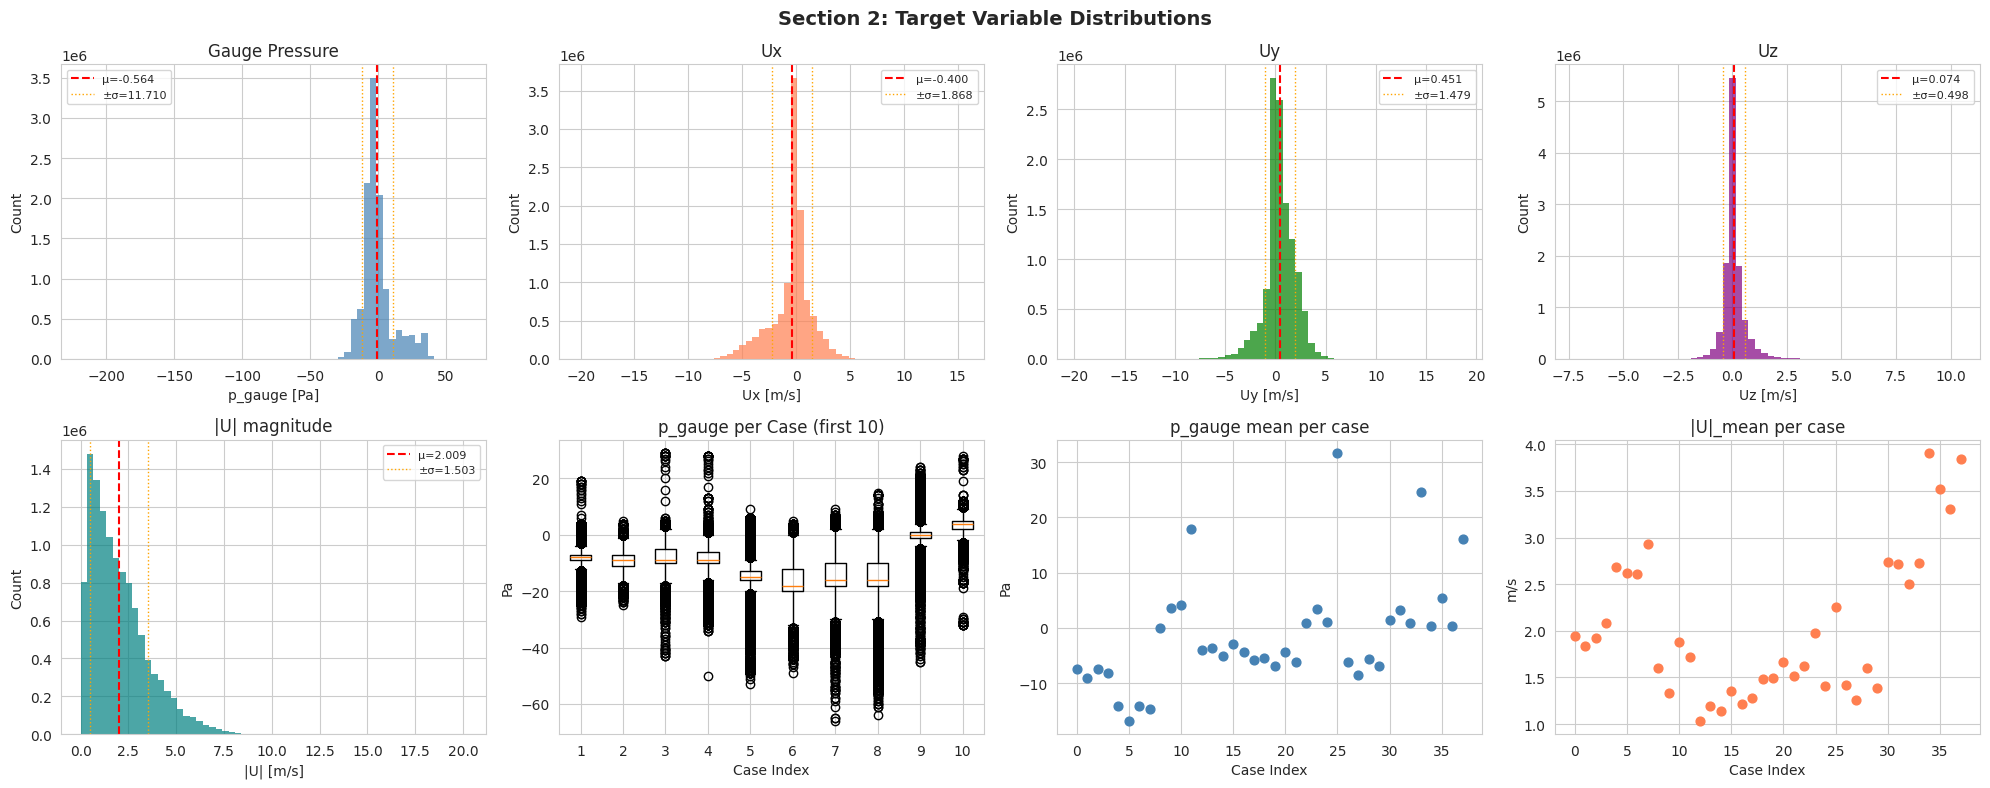

Saved: S2_target_distributions.png


In [6]:
# ═════════════════════════════════════════════════════════════════════════════
# SECTION 2: TARGET VARIABLES (p, Ux, Uy, Uz) DISTRIBUTION
# ═════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("  SECTION 2: TARGET VARIABLE DISTRIBUTIONS")
print("=" * 70)

# Aggregate all data
all_p_raw   = np.concatenate([c['p_raw']   for c in cases])
all_p_gauge = np.concatenate([c['p_gauge'] for c in cases])
all_U       = np.vstack([c['U']            for c in cases])
all_Umag    = np.linalg.norm(all_U, axis=1)

def stats_row(name, arr):
    return (f"  {name:<12}  min={arr.min():>10.4f}  max={arr.max():>10.4f}  "
            f"mean={arr.mean():>10.4f}  std={arr.std():>10.4f}  "
            f"p5={np.percentile(arr,5):>10.4f}  p95={np.percentile(arr,95):>10.4f}")

print("\n📊 RAW OpenFOAM Pressure (absolute, Pa):")
print(stats_row("p_abs [Pa]", all_p_raw))
print("\n📊 GAUGE Pressure (p - P_REF, Pa):")
print(stats_row("p_gauge [Pa]", all_p_gauge))
print("\n📊 Velocity Components [m/s]:")
print(stats_row("Ux [m/s]", all_U[:,0]))
print(stats_row("Uy [m/s]", all_U[:,1]))
print(stats_row("Uz [m/s]", all_U[:,2]))
print(stats_row("|U| [m/s]", all_Umag))

# Scale comparison
print("\n⚖️  Scale Comparison (important for ML loss weighting):")
scales = {
    'p_gauge [Pa]':  all_p_gauge.std(),
    'Ux [m/s]':      all_U[:,0].std(),
    'Uy [m/s]':      all_U[:,1].std(),
    'Uz [m/s]':      all_U[:,2].std(),
}
for k, v in scales.items():
    print(f"   {k:<20}  std = {v:.4f}")
max_scale = max(scales.values())
print("\n   Scale ratios (vs max std):")
for k, v in scales.items():
    print(f"   {k:<20}  ratio = {max_scale/v:.2f}x")

# Uz check
uz_pct = np.percentile(np.abs(all_U[:,2]), [50, 90, 99])
print(f"\n🔍 Uz significance: median|Uz|={uz_pct[0]:.4f}  p90={uz_pct[1]:.4f}  p99={uz_pct[2]:.4f}")
print(f"   Uz≈0 (|Uz| < 0.1 m/s)? {(np.abs(all_U[:,2]) < 0.1).mean()*100:.1f}% of all cells")
print(f"   → {'Uz is mostly negligible ✅' if uz_pct[1] < 0.2 else 'Uz has meaningful values ⚠️'}")

# Normalization check — is the data raw or normalized?
print(f"\n🔍 Normalization status:")
print(f"   p values are {'RAW absolute Pa (101325 range) ← needs P_REF subtraction' if all_p_raw.mean() > 1000 else 'already normalized'}")
print(f"   U values are {'RAW m/s' if all_Umag.max() < 100 else 'likely wrong scale'}")

# Plots
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Section 2: Target Variable Distributions', fontsize=14, fontweight='bold')

def hist_ax(ax, data, title, xlabel, color='steelblue', bins=60):
    ax.hist(data, bins=bins, color=color, alpha=0.7, edgecolor='none')
    ax.axvline(data.mean(), color='red', ls='--', lw=1.5, label=f'μ={data.mean():.3f}')
    ax.axvline(data.mean()+data.std(), color='orange', ls=':', lw=1, label=f'±σ={data.std():.3f}')
    ax.axvline(data.mean()-data.std(), color='orange', ls=':', lw=1)
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel('Count'); ax.legend(fontsize=8)

hist_ax(axes[0,0], all_p_gauge,   'Gauge Pressure', 'p_gauge [Pa]', 'steelblue')
hist_ax(axes[0,1], all_U[:,0],    'Ux',             'Ux [m/s]',     'coral')
hist_ax(axes[0,2], all_U[:,1],    'Uy',             'Uy [m/s]',     'green')
hist_ax(axes[0,3], all_U[:,2],    'Uz',             'Uz [m/s]',     'purple')
hist_ax(axes[1,0], all_Umag,      '|U| magnitude',  '|U| [m/s]',    'teal')

# Per-case distributions (box plots)
p_means   = [c['p_gauge'].mean()  for c in cases]
u_means   = [np.linalg.norm(c['U'],axis=1).mean() for c in cases]
axes[1,1].boxplot([c['p_gauge'] for c in cases[:10]], notch=False)
axes[1,1].set_title('p_gauge per Case (first 10)'); axes[1,1].set_xlabel('Case Index'); axes[1,1].set_ylabel('Pa')

axes[1,2].scatter(range(len(cases)), p_means, c='steelblue', s=40)
axes[1,2].set_title('p_gauge mean per case'); axes[1,2].set_xlabel('Case Index'); axes[1,2].set_ylabel('Pa')

axes[1,3].scatter(range(len(cases)), u_means, c='coral', s=40)
axes[1,3].set_title('|U|_mean per case'); axes[1,3].set_xlabel('Case Index'); axes[1,3].set_ylabel('m/s')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'S2_target_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: S2_target_distributions.png")


  SECTION 3: WIND ANGLE & DIRECTION DIVERSITY

Case                           Location                                Uinlet   Speed   Math°    Met°
----------------------------------------------------------------------------------------------------
building2                      mohali_summer                (1.700, 1.700, 0)    2.40    45.0   225.0
building3                      mohali_summer                (1.700, 1.700, 0)    2.40    45.0   225.0
building4                      mohali_summer                (1.700, 1.700, 0)    2.40    45.0   225.0
building5                      mohali_summer                (1.700, 1.700, 0)    2.40    45.0   225.0
building2                      mombasa_Summer               (2.830, 2.830, 0)    4.00    45.0   225.0
building3                      mombasa_Summer               (2.830, 2.830, 0)    4.00    45.0   225.0
building4                      mombasa_Summer               (2.830, 2.830, 0)    4.00    45.0   225.0
building5                      momba

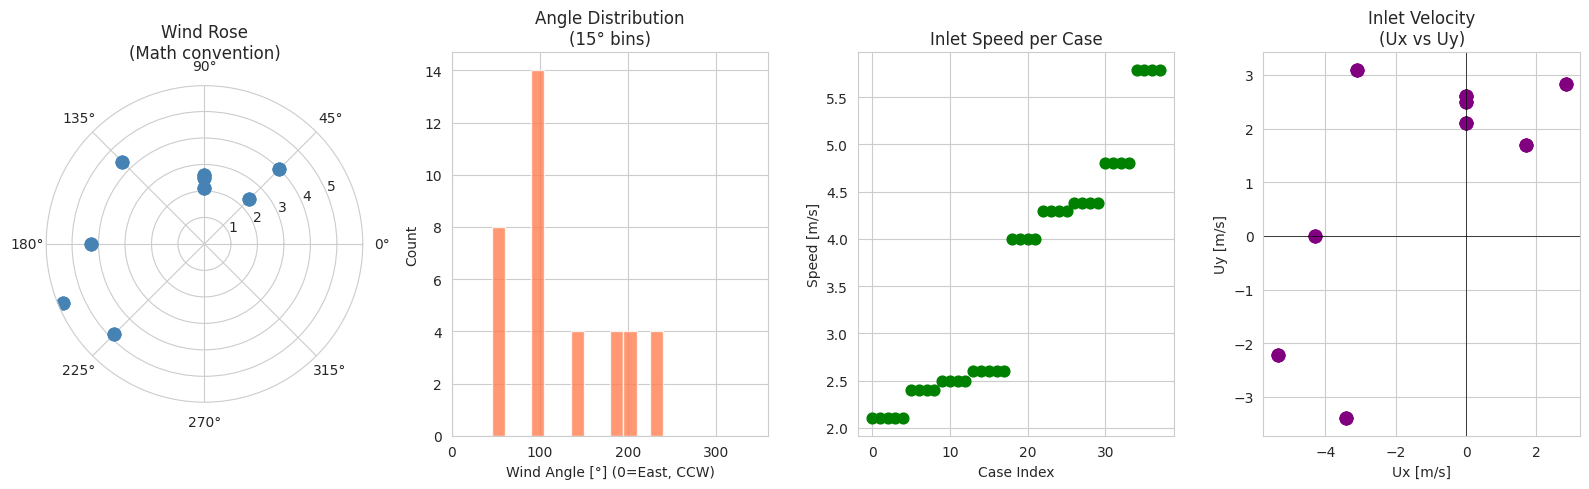

Saved: S3_wind_angles.png


In [7]:
# ═════════════════════════════════════════════════════════════════════════════
# SECTION 3: WIND ANGLE / DIRECTION ANALYSIS
# ═════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("  SECTION 3: WIND ANGLE & DIRECTION DIVERSITY")
print("=" * 70)

# Extract angle from each case
angle_data = []
for c in cases:
    ui = c['Uinlet']
    spd  = float(np.linalg.norm(ui))
    ang  = float(np.degrees(np.arctan2(ui[1], ui[0])) % 360)
    ang_met = (270 - ang) % 360   # meteorological convention (0=N, 90=E)
    angle_data.append({
        'case':    c['case_name'],
        'loc':     c['location'],
        'Uinlet':  ui,
        'speed':   spd,
        'angle_math': ang,         # mathematical (0=East, CCW)
        'angle_met':  ang_met,     # meteorological (0=North, CW)
        'Ux':     float(ui[0]),
        'Uy':     float(ui[1]),
    })

# Print table
print(f"\n{'Case':<30} {'Location':<20} {'Uinlet':>25} {'Speed':>7} {'Math°':>7} {'Met°':>7}")
print("-" * 100)
for d in sorted(angle_data, key=lambda x: x['angle_math']):
    ui_str = f"({d['Ux']:.3f}, {d['Uy']:.3f}, 0)"
    print(f"{d['case']:<30} {d['loc']:<20} {ui_str:>25} {d['speed']:>7.2f} {d['angle_math']:>7.1f} {d['angle_met']:>7.1f}")

# Unique angles
unique_angles = sorted(set(round(d['angle_math']/5)*5 for d in angle_data))
unique_speeds = sorted(set(round(d['speed'], 2) for d in angle_data))
print(f"\n🎯 Unique wind angles (math, ±5° bins):  {unique_angles}")
print(f"🎯 Unique wind speeds (±0.01 m/s bins):  {unique_speeds}")
print(f"\n⚠️  CRITICAL: Dataset has only {len(unique_angles)} unique angle(s) → very limited angular diversity!")
print(f"   For robust GNN, need at least 8 angles (every 45°)")
print(f"   → Rotation augmentation is mandatory before training")

# Angle cluster analysis
from collections import Counter
angle_bins = Counter(round(d['angle_math']/45)*45 for d in angle_data)
print(f"\n📊 Angle distribution (45° bins):")
for ang, cnt in sorted(angle_bins.items()):
    bar = '█' * cnt
    print(f"   {ang:>5.0f}°  {bar}  ({cnt} cases)")

# Polar plot
angles_rad = [np.radians(d['angle_math']) for d in angle_data]
speeds     = [d['speed'] for d in angle_data]
fig = plt.figure(figsize=(16, 5))

# Polar wind rose
ax1 = fig.add_subplot(141, polar=True)
ax1.scatter(angles_rad, speeds, c='steelblue', s=80, alpha=0.8)
ax1.set_title('Wind Rose\n(Math convention)', pad=20)
ax1.set_theta_zero_location('E')
ax1.set_theta_direction(1)   # CCW

# Angle histogram
ax2 = fig.add_subplot(142)
bins = np.arange(0, 361, 15)
ax2.hist([d['angle_math'] for d in angle_data], bins=bins, color='coral', alpha=0.8, edgecolor='white')
ax2.set_xlabel('Wind Angle [°] (0=East, CCW)'); ax2.set_ylabel('Count')
ax2.set_title('Angle Distribution\n(15° bins)'); ax2.set_xlim(0, 360)

# Speed distribution per case
ax3 = fig.add_subplot(143)
ax3.scatter(range(len(angle_data)), sorted(speeds), color='green', s=60)
ax3.set_xlabel('Case Index'); ax3.set_ylabel('Speed [m/s]')
ax3.set_title('Inlet Speed per Case')

# Ux vs Uy scatter
ax4 = fig.add_subplot(144)
ux_vals = [d['Ux'] for d in angle_data]; uy_vals = [d['Uy'] for d in angle_data]
ax4.scatter(ux_vals, uy_vals, c='purple', s=80)
ax4.axhline(0, color='k', lw=0.5); ax4.axvline(0, color='k', lw=0.5)
ax4.set_xlabel('Ux [m/s]'); ax4.set_ylabel('Uy [m/s]')
ax4.set_title('Inlet Velocity\n(Ux vs Uy)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'S3_wind_angles.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: S3_wind_angles.png")


  SECTION 4: BOUNDARY CONDITIONS

Patch              Min %    Max %   Mean %   Cases with patch
-----------------------------------------------------------------
inlet               0.14     0.58     0.29                 38/38
outlet              0.14     0.58     0.29                 38/38
ground              1.30     2.37     1.95                 38/38
buildings           0.00    36.56    14.89                 29/38
wall                0.00     0.00     0.00                  0/38

   Total boundary nodes: 22.7% ± 4.9% of all cells
   Interior cells: 77.3% of all cells

🔍 Inlet BC Consistency (Uinlet in 0/U vs field average at inlet cells):
   building2: Uinlet=[-3.1  3.1]  U@inlet_cells_mean=[-3.108  2.315]  err=0.7881 m/s
   building3: Uinlet=[-3.1  3.1]  U@inlet_cells_mean=[-3.103  1.143]  err=1.9571 m/s
   building4: Uinlet=[-3.1  3.1]  U@inlet_cells_mean=[-3.119  2.5  ]  err=0.6005 m/s
   building5: Uinlet=[-3.1  3.1]  U@inlet_cells_mean=[-3.104  2.498]  err=0.6018 m/s
   buildin

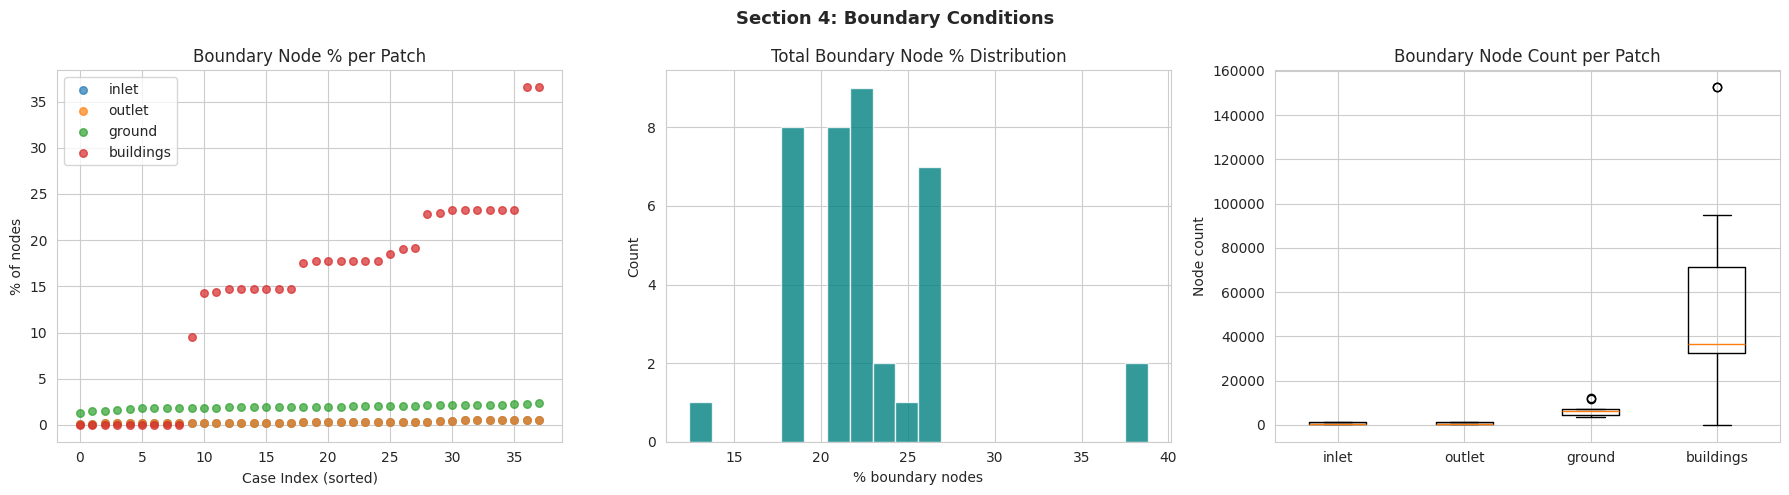

Saved: S4_boundary_conditions.png


In [8]:
# ═════════════════════════════════════════════════════════════════════════════
# SECTION 4: BOUNDARY CONDITIONS ANALYSIS
# ═════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("  SECTION 4: BOUNDARY CONDITIONS")
print("=" * 70)

bc_summary = []
for c in cases:
    bnd = c['boundary_cells']
    N   = c['n_cells']
    row = {'case': c['case_name'], 'loc': c['location'], 'N': N}
    for patch in ['inlet', 'outlet', 'ground', 'buildings', 'wall', 'top']:
        cnt = len(bnd.get(patch, set()))
        row[f'n_{patch}']   = cnt
        row[f'pct_{patch}'] = 100 * cnt / N if N > 0 else 0
    row['n_total_bnd'] = sum(len(v) for v in bnd.values())
    row['pct_bnd']     = 100 * row['n_total_bnd'] / N if N > 0 else 0
    bc_summary.append(row)

# Print patch summary
print(f"\n{'Patch':<15} {'Min %':>8} {'Max %':>8} {'Mean %':>8} {'Cases with patch':>18}")
print("-" * 65)
for patch in ['inlet', 'outlet', 'ground', 'buildings', 'wall']:
    vals = [r[f'pct_{patch}'] for r in bc_summary]
    cnt_nonzero = sum(1 for v in vals if v > 0)
    print(f"{patch:<15} {min(vals):>8.2f} {max(vals):>8.2f} {np.mean(vals):>8.2f} {cnt_nonzero:>18}/{len(cases)}")

# Total boundary %
bnd_pcts = [r['pct_bnd'] for r in bc_summary]
print(f"\n   Total boundary nodes: {np.mean(bnd_pcts):.1f}% ± {np.std(bnd_pcts):.1f}% of all cells")
print(f"   Interior cells: {100-np.mean(bnd_pcts):.1f}% of all cells")

# Inlet velocity direction consistency check
print("\n🔍 Inlet BC Consistency (Uinlet in 0/U vs field average at inlet cells):")
for c in cases[:5]:   # check first 5
    bnd = c['boundary_cells']
    if 'inlet' not in bnd or len(bnd['inlet']) == 0:
        print(f"   {c['case_name']}: no inlet cells found")
        continue
    inlet_cells = [i for i in bnd['inlet'] if i < c['n_cells']]
    U_inlet_cells = c['U'][inlet_cells]
    U_mean = U_inlet_cells.mean(axis=0)
    ui = c['Uinlet']
    err = np.linalg.norm(U_mean - ui)
    print(f"   {c['case_name']}: Uinlet={ui[:2]}  U@inlet_cells_mean={U_mean[:2].round(3)}  err={err:.4f} m/s")

# No-slip check (U near buildings/ground should be ~0)
print("\n🔍 No-slip BC Check (U near building walls):")
for c in cases[:5]:
    bnd = c['boundary_cells']
    for patch in ['buildings']:
        if patch not in bnd or len(bnd[patch]) == 0: continue
        cells_list = [i for i in bnd[patch] if i < c['n_cells']]
        if not cells_list: continue
        U_wall = c['U'][cells_list]
        Umag_wall = np.linalg.norm(U_wall, axis=1)
        print(f"   {c['case_name']} / {patch}: |U|_mean={Umag_wall.mean():.4f}  |U|_max={Umag_wall.max():.4f} m/s")
        print(f"       {'✅ no-slip OK' if Umag_wall.mean() < 0.1 else '⚠️ wall velocity too high — check mesh'}")

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Section 4: Boundary Conditions', fontsize=13, fontweight='bold')

patches_to_plot = ['inlet', 'outlet', 'ground', 'buildings']
colors = ['steelblue', 'coral', 'green', 'purple']
for patch, col in zip(patches_to_plot, colors):
    vals = [r[f'pct_{patch}'] for r in bc_summary]
    axes[0].scatter(range(len(vals)), sorted(vals), label=patch, s=30, alpha=0.7)
axes[0].set_xlabel('Case Index (sorted)'); axes[0].set_ylabel('% of nodes')
axes[0].set_title('Boundary Node % per Patch'); axes[0].legend()

axes[1].hist(bnd_pcts, bins=20, color='teal', alpha=0.8)
axes[1].set_xlabel('% boundary nodes'); axes[1].set_ylabel('Count')
axes[1].set_title('Total Boundary Node % Distribution')

# Patch count per case
patch_counts = {p: [r[f'n_{p}'] for r in bc_summary] for p in patches_to_plot}
positions = np.arange(len(patches_to_plot))
bp = axes[2].boxplot([patch_counts[p] for p in patches_to_plot], labels=patches_to_plot, notch=False)
axes[2].set_ylabel('Node count'); axes[2].set_title('Boundary Node Count per Patch')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'S4_boundary_conditions.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: S4_boundary_conditions.png")


  SECTION 5: SPATIAL DISTRIBUTION & INPUT FEATURES

📐 Domain Geometry per Case:
Case                                      X range            Y range         Z range   Domain vol
-----------------------------------------------------------------------------------------------
building2                             [-130, 130]        [-155, 155]        [0, 117]        9.4 M m³
building3                             [-367, 367]        [-353, 353]         [0, 70]       36.4 M m³
building4                               [-88, 88]          [-80, 80]         [0, 88]        2.5 M m³
building5                               [-94, 94]          [-98, 98]         [0, 29]        1.1 M m³
building2                             [-130, 130]        [-155, 155]        [0, 117]        9.4 M m³
building3                             [-367, 367]        [-353, 353]         [0, 70]       36.4 M m³
building4                               [-88, 88]          [-80, 80]         [0, 88]        2.5 M m³
building5          

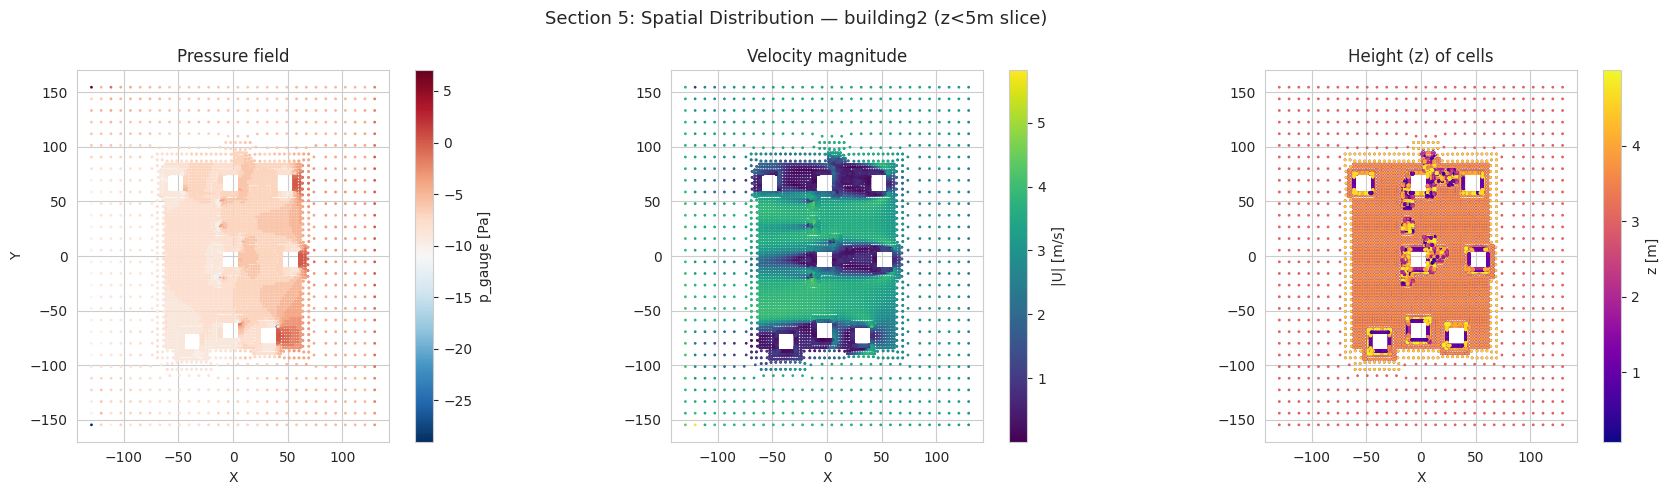

Saved: S5_spatial_distribution.png


In [9]:
# ═════════════════════════════════════════════════════════════════════════════
# SECTION 5: SPATIAL DISTRIBUTION & INPUT FEATURES (x)
# ═════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("  SECTION 5: SPATIAL DISTRIBUTION & INPUT FEATURES")
print("=" * 70)

# Domain size analysis
print("\n📐 Domain Geometry per Case:")
print(f"{'Case':<30} {'X range':>18} {'Y range':>18} {'Z range':>15} {'Domain vol':>12}")
print("-" * 95)
for c in cases:
    pts = c['cell_centers']
    xr  = f"[{pts[:,0].min():.0f}, {pts[:,0].max():.0f}]"
    yr  = f"[{pts[:,1].min():.0f}, {pts[:,1].max():.0f}]"
    zr  = f"[{pts[:,2].min():.0f}, {pts[:,2].max():.0f}]"
    vol = (pts[:,0].max()-pts[:,0].min()) * (pts[:,1].max()-pts[:,1].min()) * (pts[:,2].max()-pts[:,2].min())
    print(f"{c['case_name']:<30} {xr:>18} {yr:>18} {zr:>15} {vol/1e6:>10.1f} M m³")

# Z-height distribution
all_z = np.concatenate([c['cell_centers'][:,2] for c in cases])
print(f"\n📊 Height (Z) distribution across all cases:")
print(f"   z min:  {all_z.min():.2f} m")
print(f"   z max:  {all_z.max():.2f} m")
print(f"   z mean: {all_z.mean():.2f} m")
for z_thresh in [2, 5, 10, 20]:
    pct = (all_z < z_thresh).mean() * 100
    print(f"   z < {z_thresh:2d} m:  {pct:.1f}% of cells")

# Near-wall resolution check
print("\n🔍 Near-building cell density:")
for c in cases[:5]:
    bnd = c['boundary_cells']; pts = c['cell_centers']
    if 'buildings' not in bnd or len(bnd['buildings']) == 0: continue
    bld_cells = np.array([i for i in bnd['buildings'] if i < c['n_cells']])
    if len(bld_cells) == 0: continue
    tree = cKDTree(pts[bld_cells])
    _, d = tree.query(pts, k=1)
    pct_near = (d < 1.0).mean() * 100
    pct_near5 = (d < 5.0).mean() * 100
    print(f"   {c['case_name']}: cells within 1m of building: {pct_near:.1f}%  within 5m: {pct_near5:.1f}%")

# Horizontal slice visualization — first case
c0 = cases[0]
pts = c0['cell_centers']
mask_z = pts[:,2] < 5.0

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Section 5: Spatial Distribution — {c0["case_name"]} (z<5m slice)', fontsize=13)

sc0 = axes[0].scatter(pts[mask_z,0], pts[mask_z,1], c=c0['p_gauge'][mask_z], cmap='RdBu_r', s=1)
plt.colorbar(sc0, ax=axes[0], label='p_gauge [Pa]')
axes[0].set_title('Pressure field'); axes[0].set_aspect('equal'); axes[0].set_xlabel('X'); axes[0].set_ylabel('Y')

sc1 = axes[1].scatter(pts[mask_z,0], pts[mask_z,1], c=np.linalg.norm(c0['U'][mask_z], axis=1), cmap='viridis', s=1)
plt.colorbar(sc1, ax=axes[1], label='|U| [m/s]')
axes[1].set_title('Velocity magnitude'); axes[1].set_aspect('equal'); axes[1].set_xlabel('X')

sc2 = axes[2].scatter(pts[mask_z,0], pts[mask_z,1], c=pts[mask_z,2], cmap='plasma', s=1)
plt.colorbar(sc2, ax=axes[2], label='z [m]')
axes[2].set_title('Height (z) of cells'); axes[2].set_aspect('equal'); axes[2].set_xlabel('X')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'S5_spatial_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: S5_spatial_distribution.png")


  SECTION 6: CORRELATION & PHYSICS CONSISTENCY

📊 Correlation Matrix (building2):
             p_gauge        Ux        Uy        Uz       |U|
   p_gauge     1.000     0.008     0.040     0.111     0.064
        Ux     0.008     1.000     0.020    -0.148    -0.923
        Uy     0.040     0.020     1.000    -0.101    -0.057
        Uz     0.111    -0.148    -0.101     1.000     0.145
       |U|     0.064    -0.923    -0.057     0.145     1.000

🔍 Bernoulli Check (interior cells, away from walls):
   Dynamic pressure range: 0.00 – 20.76 Pa
   Total pressure (p + 0.5ρ|U|²) std: 3.693 Pa
   (Should be small far from building; large near walls due to viscosity)

🔍 Stagnation Points (|U| < 10% of Uinlet speed):
   Cells with |U| < 10% Uinlet: 34170 (9.1%)
   Stagnation region centroid: x=8.5  y=8.9  z=21.8

🔍 Wake Region (downstream + low speed):
   Wake cells: 129660 (34.7%)

📊 Pressure vs |U| correlation: 0.064
   (Should be negative: higher speed → lower pressure — Bernoulli)


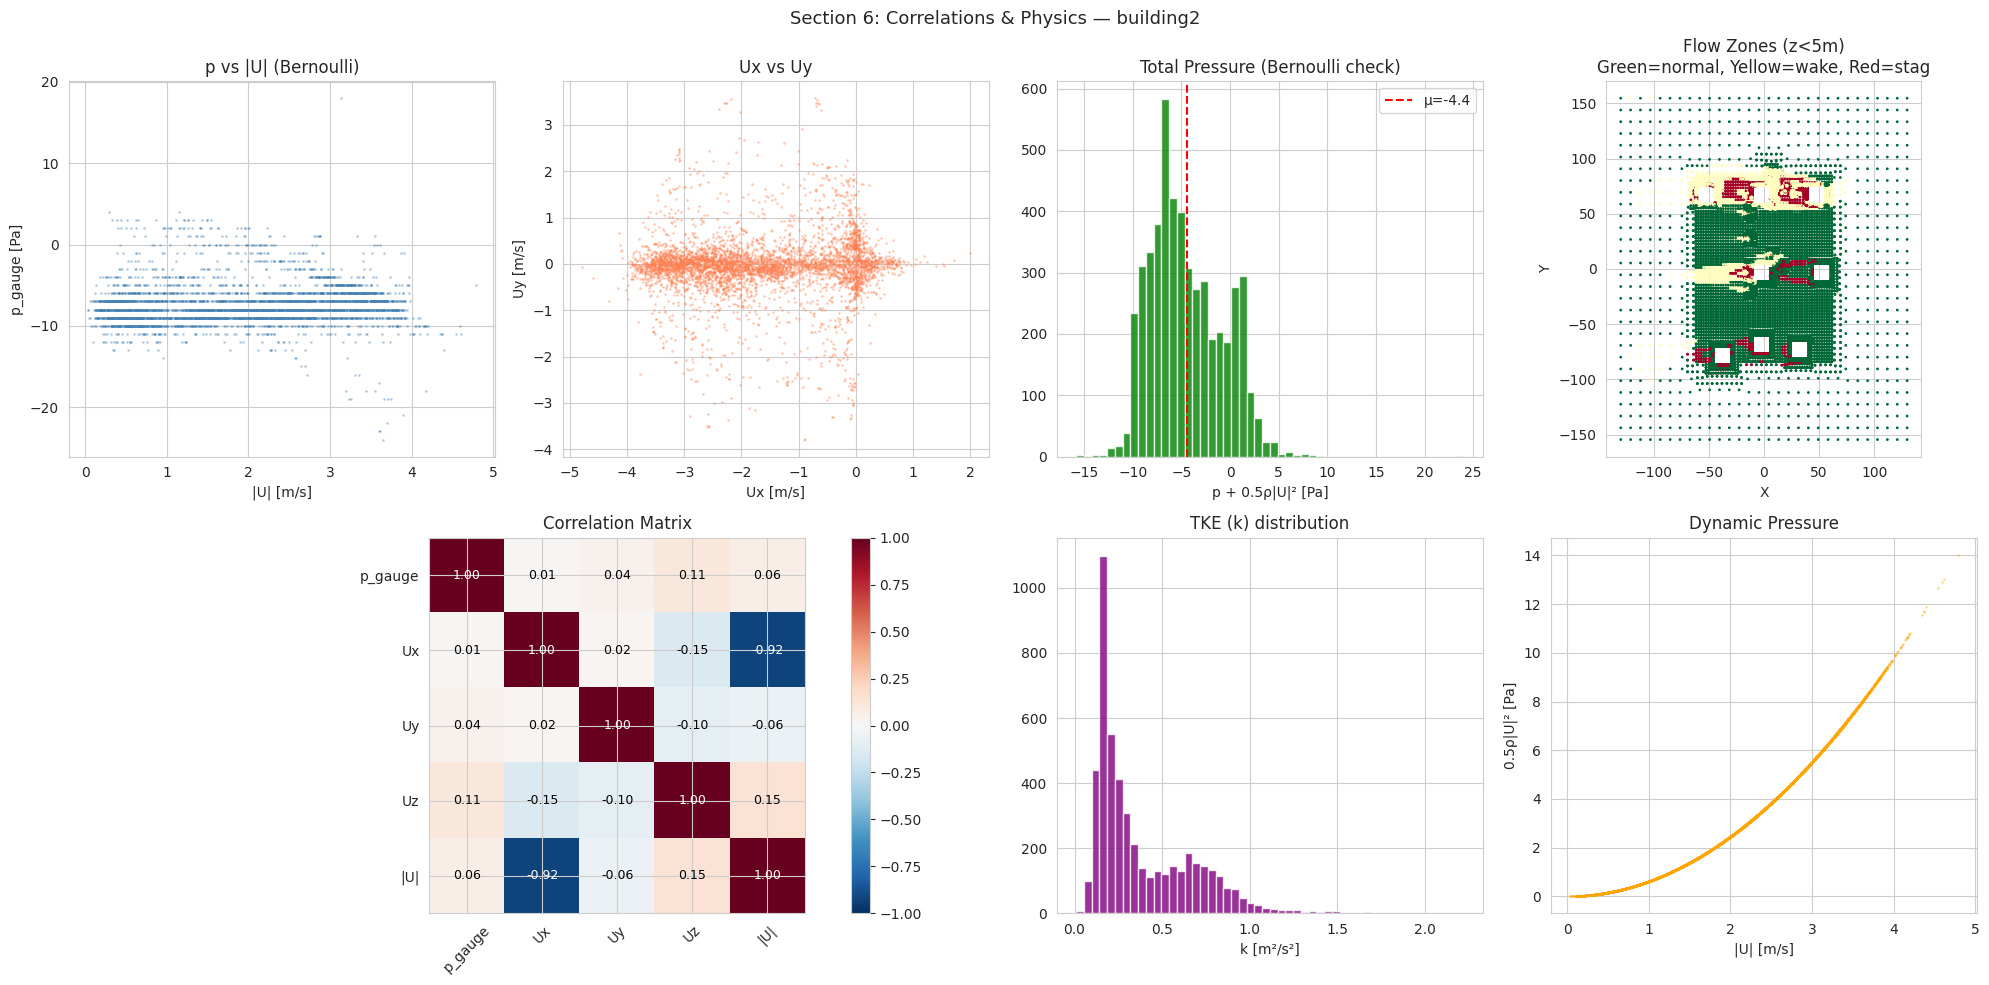

Saved: S6_correlations.png


In [10]:
# ═════════════════════════════════════════════════════════════════════════════
# SECTION 6: CORRELATION & PHYSICS CONSISTENCY
# ═════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("  SECTION 6: CORRELATION & PHYSICS CONSISTENCY")
print("=" * 70)

# Use first case for detailed analysis
c0    = cases[0]
p_g   = c0['p_gauge']
U     = c0['U']
Umag  = np.linalg.norm(U, axis=1)
pts   = c0['cell_centers']

# 6.1 Correlation matrix
print(f"\n📊 Correlation Matrix ({c0['case_name']}):")
fields = {'p_gauge': p_g, 'Ux': U[:,0], 'Uy': U[:,1], 'Uz': U[:,2], '|U|': Umag}
names  = list(fields.keys()); arrs = [fields[n] for n in names]
corr_mat = np.corrcoef(arrs)
print(f"{'':>10}", end='')
for n in names: print(f"  {n:>8}", end='')
print()
for i, n1 in enumerate(names):
    print(f"{n1:>10}", end='')
    for j in range(len(names)):
        print(f"  {corr_mat[i,j]:>8.3f}", end='')
    print()

# 6.2 Bernoulli check: p + 0.5*rho*|U|^2 = const at high-speed regions
dyn_p   = 0.5 * RHO * Umag**2   # dynamic pressure [Pa]
total_p = p_g + dyn_p            # should be roughly constant in inviscid regions
print(f"\n🔍 Bernoulli Check (interior cells, away from walls):")
print(f"   Dynamic pressure range: {dyn_p.min():.2f} – {dyn_p.max():.2f} Pa")
print(f"   Total pressure (p + 0.5ρ|U|²) std: {total_p.std():.3f} Pa")
print(f"   (Should be small far from building; large near walls due to viscosity)")

# 6.3 Stagnation point detection
print(f"\n🔍 Stagnation Points (|U| < 10% of Uinlet speed):")
U_inlet_mag = float(np.linalg.norm(c0['Uinlet']))
stag_mask   = Umag < 0.10 * U_inlet_mag
print(f"   Cells with |U| < 10% Uinlet: {stag_mask.sum()} ({100*stag_mask.mean():.1f}%)")
if stag_mask.sum() > 0:
    stag_pts = pts[stag_mask]
    print(f"   Stagnation region centroid: x={stag_pts[:,0].mean():.1f}  y={stag_pts[:,1].mean():.1f}  z={stag_pts[:,2].mean():.1f}")

# 6.4 Wake detection
wind_dir = c0['Uinlet'] / (U_inlet_mag + 1e-8)
along_flow = (pts - pts.mean(axis=0)) @ wind_dir
wake_mask  = (along_flow > 0) & (Umag < 0.6 * U_inlet_mag)
print(f"\n🔍 Wake Region (downstream + low speed):")
print(f"   Wake cells: {wake_mask.sum()} ({100*wake_mask.mean():.1f}%)")

# 6.5 Pressure-velocity relationship
print(f"\n📊 Pressure vs |U| correlation: {np.corrcoef(p_g, Umag)[0,1]:.3f}")
print(f"   (Should be negative: higher speed → lower pressure — Bernoulli)")

# Plots
fig = plt.figure(figsize=(20, 10))
gs  = GridSpec(2, 4, figure=fig)
fig.suptitle(f'Section 6: Correlations & Physics — {c0["case_name"]}', fontsize=13)

# p vs |U| scatter
ax = fig.add_subplot(gs[0,0])
sample_idx = np.random.choice(len(p_g), min(5000, len(p_g)), replace=False)
ax.scatter(Umag[sample_idx], p_g[sample_idx], s=1, alpha=0.3, c='steelblue')
ax.set_xlabel('|U| [m/s]'); ax.set_ylabel('p_gauge [Pa]')
ax.set_title('p vs |U| (Bernoulli)')

# Ux vs Uy
ax = fig.add_subplot(gs[0,1])
ax.scatter(U[sample_idx,0], U[sample_idx,1], s=1, alpha=0.3, c='coral')
ax.set_xlabel('Ux [m/s]'); ax.set_ylabel('Uy [m/s]')
ax.set_title('Ux vs Uy')

# Total pressure (Bernoulli)
ax = fig.add_subplot(gs[0,2])
ax.hist(total_p[sample_idx], bins=50, color='green', alpha=0.8)
ax.axvline(np.mean(total_p), color='red', ls='--', label=f'μ={np.mean(total_p):.1f}')
ax.set_xlabel('p + 0.5ρ|U|² [Pa]'); ax.set_title('Total Pressure (Bernoulli check)'); ax.legend()

# Stagnation + wake map
ax = fig.add_subplot(gs[0,3])
mask_z = pts[:,2] < 5
color_code = np.zeros(len(pts))
color_code[wake_mask] = 1; color_code[stag_mask] = 2
ax.scatter(pts[mask_z,0], pts[mask_z,1], c=color_code[mask_z], cmap='RdYlGn_r', s=1, vmin=0, vmax=2)
ax.set_title('Flow Zones (z<5m)\nGreen=normal, Yellow=wake, Red=stag')
ax.set_aspect('equal'); ax.set_xlabel('X'); ax.set_ylabel('Y')

# Corr matrix heatmap
ax = fig.add_subplot(gs[1,0:2])
im = ax.imshow(corr_mat, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=45)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f'{corr_mat[i,j]:.2f}', ha='center', va='center', fontsize=9,
                color='white' if abs(corr_mat[i,j]) > 0.5 else 'black')
ax.set_title('Correlation Matrix'); plt.colorbar(im, ax=ax)

# Turbulence field
ax = fig.add_subplot(gs[1,2])
if c0['k'] is not None:
    ax.hist(c0['k'][:len(sample_idx)], bins=50, color='purple', alpha=0.8)
    ax.set_xlabel('k [m²/s²]'); ax.set_title('TKE (k) distribution')
else:
    ax.text(0.5, 0.5, 'k not available', transform=ax.transAxes, ha='center'); ax.set_title('TKE')

ax = fig.add_subplot(gs[1,3])
ax.scatter(Umag[sample_idx], dyn_p[sample_idx], s=1, alpha=0.3, c='orange')
ax.set_xlabel('|U| [m/s]'); ax.set_ylabel('0.5ρ|U|² [Pa]')
ax.set_title('Dynamic Pressure')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'S6_correlations.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: S6_correlations.png")


  SECTION 7: NORMALIZATION ANALYSIS

📊 Global Normalization Stats (all cases):
   p_gauge:    mean=-0.564 Pa   std=11.710 Pa
   Ux:         mean=-0.400 m/s  std=1.868 m/s
   Uy:         mean=0.451 m/s  std=1.479 m/s
   Uz:         mean=0.074 m/s  std=0.498 m/s
   Ui_mean:    [-1.2231577634811401, 1.0931581258773804, 0.0]
   Ui_std:     [2.6151041984558105, 2.19706392288208, 0.0]

⚠️  Directional Bias in Inlet Velocity (Ui_mean):
   Ui_mean = [-1.22315776  1.09315813  0.        ]
   ❌ BIAS DETECTED! Ui_mean is not ~[0,0] → only 5 angle(s) in dataset
   → Rotation augmentation will fix this (8 symmetric rotations → Ui_mean → [0,0])

🔍 Per-case p_mean consistency:
   p_mean range: -16.79 – 31.63 Pa
   p_std  range: 1.10 – 10.30 Pa
   ⚠️ Large variation across cases

📊 After Z-score normalization:
   p_norm:  mean=0.0000  std=1.0000  (should be ≈0, ≈1)
   Ux_norm: mean=-0.0000  std=1.0000
   p_gauge      kurtosis=1.81  3σ-outliers=1.05%  ✅ normal-ish
   Ux           kurtosis=1.57  3σ-outli

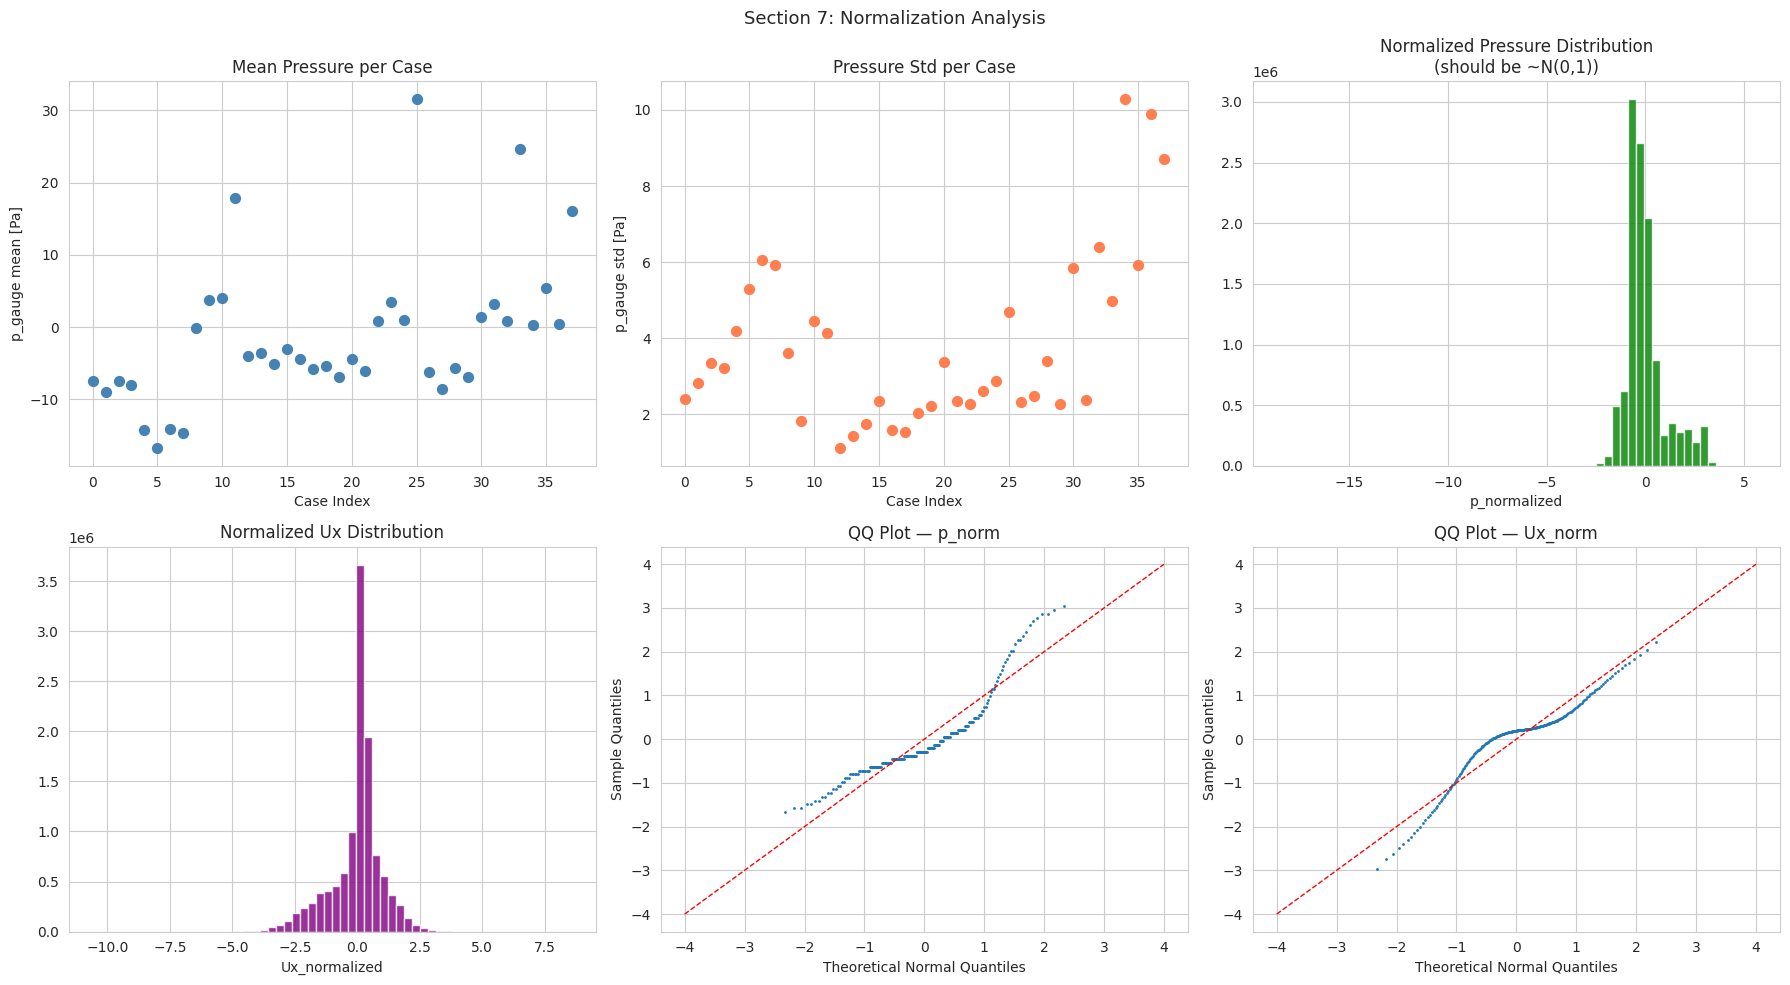

Saved: S7_normalization.png


In [11]:
# ═════════════════════════════════════════════════════════════════════════════
# SECTION 7: NORMALIZATION ANALYSIS & DATASET BALANCE
# ═════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("  SECTION 7: NORMALIZATION ANALYSIS")
print("=" * 70)

all_p_g = np.concatenate([c['p_gauge'] for c in cases])
all_U   = np.vstack([c['U'] for c in cases])
all_pts = np.vstack([c['cell_centers'] for c in cases])
all_Ui  = np.vstack([c['Uinlet'][None,:] for c in cases])

# Global stats
NORM_GLOBAL = {
    'p_mean': all_p_g.mean(), 'p_std': all_p_g.std(),
    'Ux_mean': all_U[:,0].mean(), 'Ux_std': all_U[:,0].std(),
    'Uy_mean': all_U[:,1].mean(), 'Uy_std': all_U[:,1].std(),
    'Uz_mean': all_U[:,2].mean(), 'Uz_std': all_U[:,2].std(),
    'x_mean': all_pts[:,0].mean(), 'x_std': all_pts[:,0].std(),
    'y_mean': all_pts[:,1].mean(), 'y_std': all_pts[:,1].std(),
    'z_mean': all_pts[:,2].mean(), 'z_std': all_pts[:,2].std(),
    'Ui_mean': all_Ui.mean(axis=0).tolist(), 'Ui_std': all_Ui.std(axis=0).tolist(),
}

print("\n📊 Global Normalization Stats (all cases):")
print(f"   p_gauge:    mean={NORM_GLOBAL['p_mean']:.3f} Pa   std={NORM_GLOBAL['p_std']:.3f} Pa")
print(f"   Ux:         mean={NORM_GLOBAL['Ux_mean']:.3f} m/s  std={NORM_GLOBAL['Ux_std']:.3f} m/s")
print(f"   Uy:         mean={NORM_GLOBAL['Uy_mean']:.3f} m/s  std={NORM_GLOBAL['Uy_std']:.3f} m/s")
print(f"   Uz:         mean={NORM_GLOBAL['Uz_mean']:.3f} m/s  std={NORM_GLOBAL['Uz_std']:.3f} m/s")
print(f"   Ui_mean:    {NORM_GLOBAL['Ui_mean']}")
print(f"   Ui_std:     {NORM_GLOBAL['Ui_std']}")

# Bias check
print(f"\n⚠️  Directional Bias in Inlet Velocity (Ui_mean):")
ui_mean = np.array(NORM_GLOBAL['Ui_mean'])
print(f"   Ui_mean = {ui_mean}")
if np.linalg.norm(ui_mean[:2]) > 0.5:
    print(f"   ❌ BIAS DETECTED! Ui_mean is not ~[0,0] → only {len(set(round(np.degrees(np.arctan2(c['Uinlet'][1],c['Uinlet'][0]))%360/45)*45 for c in cases))} angle(s) in dataset")
    print(f"   → Rotation augmentation will fix this (8 symmetric rotations → Ui_mean → [0,0])")
else:
    print(f"   ✅ No directional bias (Ui_mean ≈ [0,0])")

# Per-case mean check (consistency)
print(f"\n🔍 Per-case p_mean consistency:")
p_means = [c['p_gauge'].mean() for c in cases]
p_stds  = [c['p_gauge'].std()  for c in cases]
print(f"   p_mean range: {min(p_means):.2f} – {max(p_means):.2f} Pa")
print(f"   p_std  range: {min(p_stds):.2f} – {max(p_stds):.2f} Pa")
print(f"   {'✅ Consistent' if max(p_means)-min(p_means) < 10 else '⚠️ Large variation across cases'}")

# After-normalization check: normalized data should be ~N(0,1)
p_norm  = (all_p_g - NORM_GLOBAL['p_mean']) / (NORM_GLOBAL['p_std'] + 1e-8)
Ux_norm = (all_U[:,0] - NORM_GLOBAL['Ux_mean']) / (NORM_GLOBAL['Ux_std'] + 1e-8)
print(f"\n📊 After Z-score normalization:")
print(f"   p_norm:  mean={p_norm.mean():.4f}  std={p_norm.std():.4f}  (should be ≈0, ≈1)")
print(f"   Ux_norm: mean={Ux_norm.mean():.4f}  std={Ux_norm.std():.4f}")

# Kurtosis / outlier check
for name, arr in [('p_gauge', all_p_g), ('Ux', all_U[:,0]), ('|U|', np.linalg.norm(all_U,axis=1))]:
    k = stats.kurtosis(arr)
    pct_out = np.mean((np.abs(arr - arr.mean()) > 3*arr.std())) * 100
    print(f"   {name:<12} kurtosis={k:.2f}  3σ-outliers={pct_out:.2f}%  {'⚠️ heavy tails' if abs(k)>5 else '✅ normal-ish'}")

# Plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Section 7: Normalization Analysis', fontsize=13)

axes[0,0].scatter(range(len(cases)), p_means, c='steelblue', s=50)
axes[0,0].set_xlabel('Case Index'); axes[0,0].set_ylabel('p_gauge mean [Pa]'); axes[0,0].set_title('Mean Pressure per Case')

axes[0,1].scatter(range(len(cases)), p_stds, c='coral', s=50)
axes[0,1].set_xlabel('Case Index'); axes[0,1].set_ylabel('p_gauge std [Pa]'); axes[0,1].set_title('Pressure Std per Case')

axes[0,2].hist(p_norm, bins=60, color='green', alpha=0.8)
axes[0,2].set_xlabel('p_normalized'); axes[0,2].set_title('Normalized Pressure Distribution\n(should be ~N(0,1))')

axes[1,0].hist(Ux_norm, bins=60, color='purple', alpha=0.8)
axes[1,0].set_xlabel('Ux_normalized'); axes[1,0].set_title('Normalized Ux Distribution')

# QQ plot
for i, (name, arr_n) in enumerate([('p_norm', p_norm), ('Ux_norm', Ux_norm)]):
    ax = axes[1, i+1]
    q = np.percentile(arr_n, np.linspace(1, 99, 200))
    q_normal = stats.norm.ppf(np.linspace(0.01, 0.99, 200))
    ax.plot(q_normal, q, '.', ms=2)
    ax.plot([-4,4], [-4,4], 'r--', lw=1)
    ax.set_xlabel('Theoretical Normal Quantiles'); ax.set_ylabel('Sample Quantiles')
    ax.set_title(f'QQ Plot — {name}')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'S7_normalization.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: S7_normalization.png")


  SECTION 8: CROSS-CASE COMPARISON & BALANCE

🌪️  Speed diversity:  9 unique speeds: [2.1, 2.4, 2.5, 2.6, 4.0, 4.3, 4.4, 4.8, 5.8]
🧭 Angle diversity:  6 unique angles (5° bins): [45, 90, 135, 180, 205, 225]

Speed distribution:
   2.10 m/s  →    5 cases
   2.40 m/s  →    4 cases
   2.50 m/s  →    4 cases
   2.60 m/s  →    5 cases
   4.00 m/s  →    4 cases
   4.30 m/s  →    4 cases
   4.38 m/s  →    4 cases
   4.81 m/s  →    4 cases
   5.79 m/s  →    4 cases
   building2: speed=4.38  L_est=51.9m  Re≈15164909
   building3: speed=4.38  L_est=146.8m  Re≈42907296
   building4: speed=4.38  L_est=35.1m  Re≈10255490
   building5: speed=4.38  L_est=37.8m  Re≈11033253
   building2: speed=4.30  L_est=51.9m  Re≈14874132

📊 Pressure range per case:
   building2                       Δp=   48.00 Pa  q_ref= 11.77 Pa  Cp_range= 4.08
   building3                       Δp=   30.00 Pa  q_ref= 11.77 Pa  Cp_range= 2.55
   building4                       Δp=   72.00 Pa  q_ref= 11.77 Pa  Cp_range= 6.12
   bu

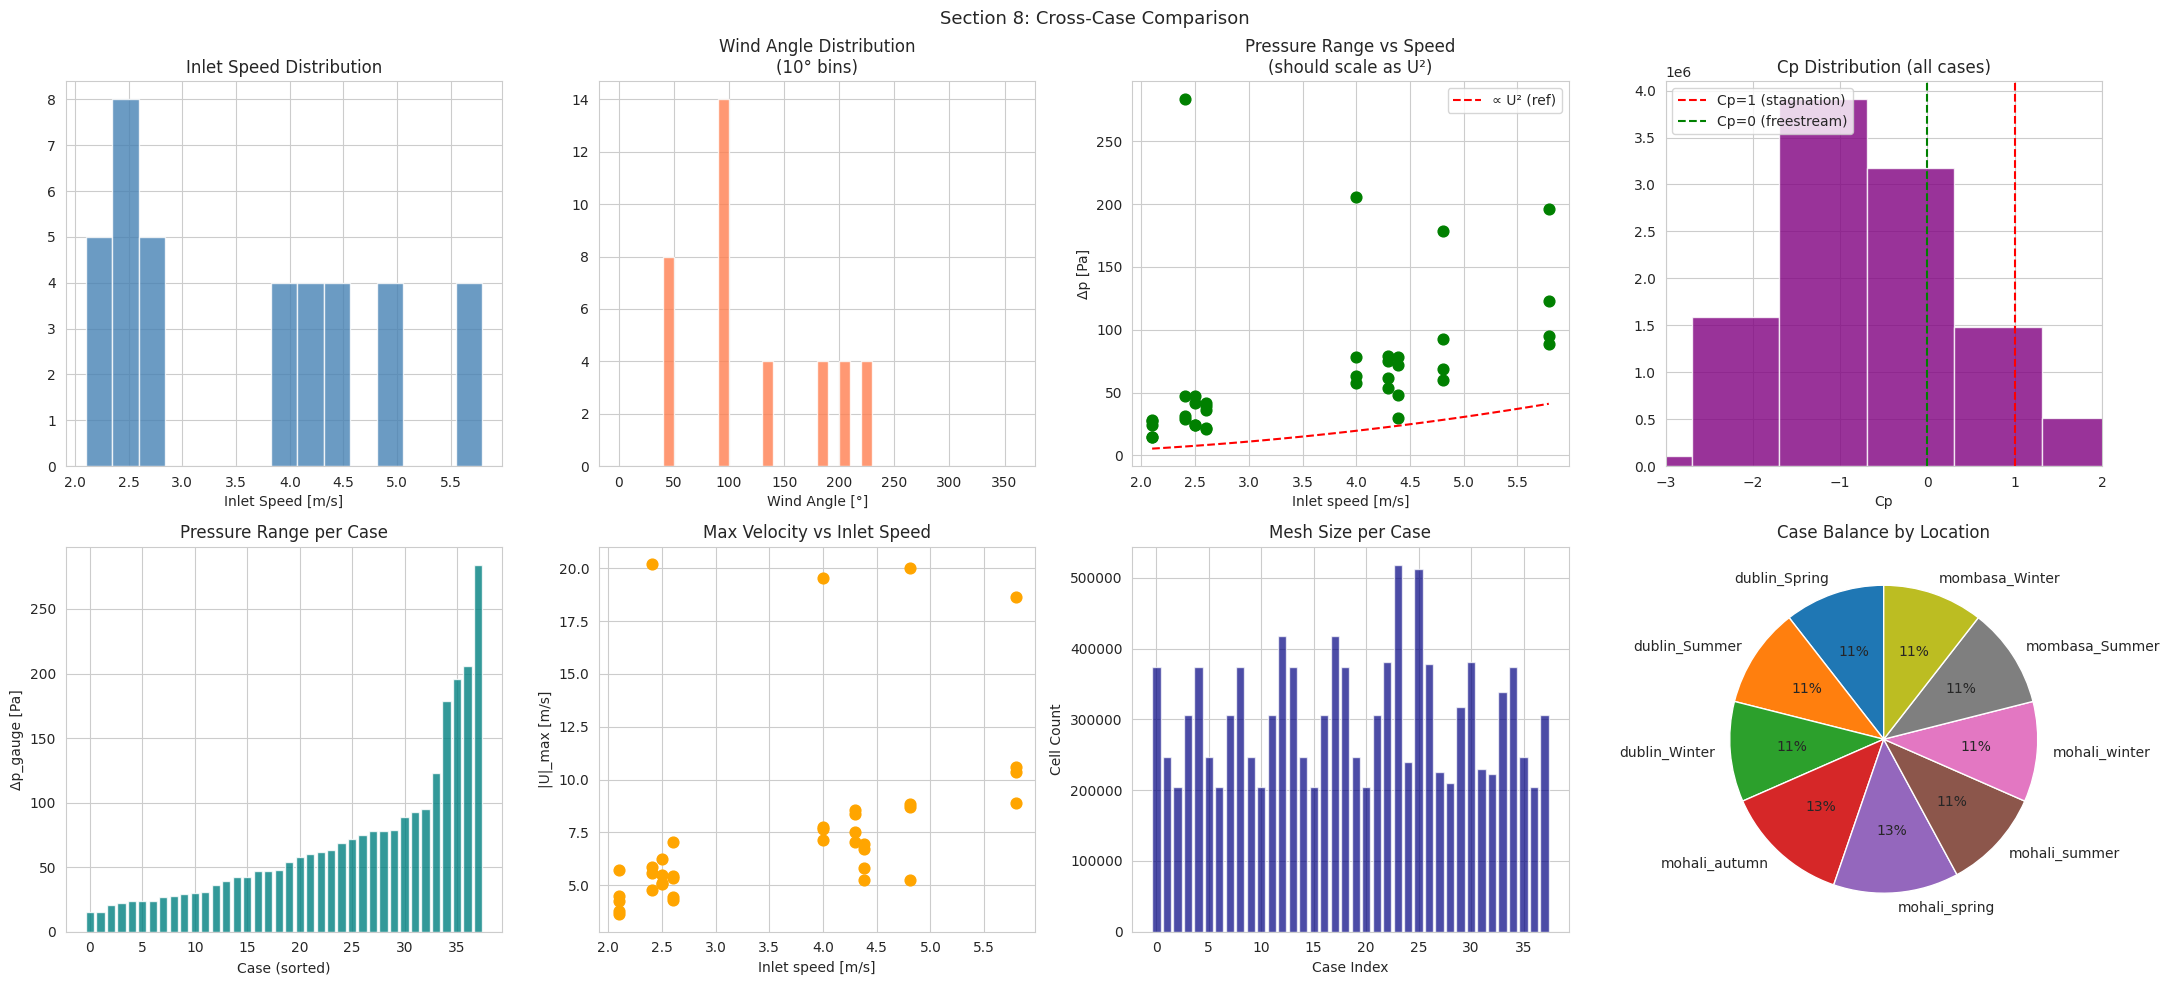

Saved: S8_cross_case.png


In [12]:
# ═════════════════════════════════════════════════════════════════════════════
# SECTION 8: CROSS-CASE COMPARISON & DATASET BALANCE
# ═════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("  SECTION 8: CROSS-CASE COMPARISON & BALANCE")
print("=" * 70)

# 8.1 Speed diversity
speeds    = [float(np.linalg.norm(c['Uinlet'])) for c in cases]
angles    = [float(np.degrees(np.arctan2(c['Uinlet'][1], c['Uinlet'][0])) % 360) for c in cases]
locations = [c['location'] for c in cases]

unique_sp = sorted(set(round(s, 1) for s in speeds))
unique_an = sorted(set(round(a/5)*5 for a in angles))
print(f"\n🌪️  Speed diversity:  {len(unique_sp)} unique speeds: {unique_sp}")
print(f"🧭 Angle diversity:  {len(unique_an)} unique angles (5° bins): {unique_an}")

# Speed distribution
sp_counter = defaultdict(int)
for s in speeds: sp_counter[round(s, 2)] += 1
print(f"\nSpeed distribution:")
for sp, cnt in sorted(sp_counter.items()):
    print(f"   {sp:.2f} m/s  →  {cnt:>3} cases")

# Reynolds number
for c in cases[:5]:
    spd = np.linalg.norm(c['Uinlet'])
    # Building width estimate from OBJ or bounding box
    pts = c['cell_centers']
    L   = (pts[:,0].max() - pts[:,0].min()) * 0.2   # approx building width
    Re  = spd * L / NU
    print(f"   {c['case_name']}: speed={spd:.2f}  L_est={L:.1f}m  Re≈{Re:.0f}")

# 8.2 p range diversity across cases
print(f"\n📊 Pressure range per case:")
p_ranges = []
for c in cases:
    p_r = c['p_gauge'].max() - c['p_gauge'].min()
    p_ranges.append(p_r)
    ui_spd = np.linalg.norm(c['Uinlet'])
    q_ref  = 0.5 * RHO * ui_spd**2   # dynamic pressure [Pa]
    cp_range = p_r / q_ref if q_ref > 0 else 0
    print(f"   {c['case_name']:<30}  Δp={p_r:>8.2f} Pa  q_ref={q_ref:>6.2f} Pa  Cp_range={cp_range:>5.2f}")

# 8.3 Cp distribution (pressure coefficient)
print(f"\n🔍 Pressure Coefficient (Cp = p_gauge / (0.5ρU²)) Statistics:")
all_cp = []
for c in cases:
    spd = np.linalg.norm(c['Uinlet'])
    q   = 0.5 * RHO * spd**2
    cp  = c['p_gauge'] / q if q > 0 else np.zeros_like(c['p_gauge'])
    all_cp.append(cp)
all_cp_cat = np.concatenate(all_cp)
print(f"   Cp range: {all_cp_cat.min():.3f} – {all_cp_cat.max():.3f}")
print(f"   Cp mean:  {all_cp_cat.mean():.3f}  std: {all_cp_cat.std():.3f}")
print(f"   Stagnation (Cp≈1): {(np.abs(all_cp_cat-1)<0.1).mean()*100:.1f}% of cells")
print(f"   Suction (Cp<-0.5): {(all_cp_cat<-0.5).mean()*100:.1f}% of cells")

# Plots
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('Section 8: Cross-Case Comparison', fontsize=13)

# Speed distribution
axes[0,0].hist(speeds, bins=15, color='steelblue', alpha=0.8, edgecolor='white')
axes[0,0].set_xlabel('Inlet Speed [m/s]'); axes[0,0].set_title('Inlet Speed Distribution')

# Angle distribution
axes[0,1].hist(angles, bins=np.arange(0,361,10), color='coral', alpha=0.8, edgecolor='white')
axes[0,1].set_xlabel('Wind Angle [°]'); axes[0,1].set_title('Wind Angle Distribution\n(10° bins)')

# p_range vs speed
axes[0,2].scatter(speeds, p_ranges, c='green', s=60)
axes[0,2].set_xlabel('Inlet speed [m/s]'); axes[0,2].set_ylabel('Δp [Pa]')
axes[0,2].set_title('Pressure Range vs Speed\n(should scale as U²)')
# Overlay theoretical U² curve
u_th = np.linspace(min(speeds), max(speeds), 50)
p_th = 0.5 * RHO * u_th**2 * 2   # rough approximation
axes[0,2].plot(u_th, p_th, 'r--', label='∝ U² (ref)'); axes[0,2].legend()

# Cp distribution
axes[0,3].hist(all_cp_cat, bins=80, color='purple', alpha=0.8)
axes[0,3].axvline(1.0, color='red', ls='--', label='Cp=1 (stagnation)')
axes[0,3].axvline(0.0, color='green', ls='--', label='Cp=0 (freestream)')
axes[0,3].set_xlabel('Cp'); axes[0,3].set_title('Cp Distribution (all cases)')
axes[0,3].legend(); axes[0,3].set_xlim(-3, 2)

# Per-case p_range bar
axes[1,0].bar(range(len(cases)), sorted(p_ranges), color='teal', alpha=0.8)
axes[1,0].set_xlabel('Case (sorted)'); axes[1,0].set_ylabel('Δp_gauge [Pa]'); axes[1,0].set_title('Pressure Range per Case')

# Per-case |U|_max
u_maxs = [np.linalg.norm(c['U'],axis=1).max() for c in cases]
axes[1,1].scatter(speeds, u_maxs, c='orange', s=60)
axes[1,1].set_xlabel('Inlet speed [m/s]'); axes[1,1].set_ylabel('|U|_max [m/s]')
axes[1,1].set_title('Max Velocity vs Inlet Speed')

# Per-case n_cells
axes[1,2].bar(range(len(cases)), [c['n_cells'] for c in cases], color='navy', alpha=0.7)
axes[1,2].set_xlabel('Case Index'); axes[1,2].set_ylabel('Cell Count'); axes[1,2].set_title('Mesh Size per Case')

# Location balance
loc_names = sorted(set(locations))
loc_vals  = [locations.count(l) for l in loc_names]
axes[1,3].pie(loc_vals, labels=loc_names, autopct='%1.0f%%', startangle=90)
axes[1,3].set_title('Case Balance by Location')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'S8_cross_case.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: S8_cross_case.png")


  SECTION 9: SPATIAL SMOOTHNESS & GRADIENT

Computing gradients for building2...
  |∇p|  mean=0.3088  std=0.9435  max=29.4923 Pa/m
  |∇|U|| mean=0.1546  std=0.2294  max=2.3066 (m/s)/m

  High ∇p region (top 10%): 500 cells
    centroid: x=13.6  y=-3.8  z=31.4
  High ∇|U| region (top 10%): 500 cells

  |∇Uz| mean=0.0510 — Uz has 3D structure

📊 Smoothness check (all cases):
  building2                       |∇p|_mean=0.325 Pa/m  |∇U|_mean=0.147 (m/s)/m
  building3                       |∇p|_mean=0.035 Pa/m  |∇U|_mean=0.069 (m/s)/m
  building4                       |∇p|_mean=0.547 Pa/m  |∇U|_mean=0.213 (m/s)/m
  building5                       |∇p|_mean=0.708 Pa/m  |∇U|_mean=0.368 (m/s)/m
  building2                       |∇p|_mean=0.552 Pa/m  |∇U|_mean=0.209 (m/s)/m
  building3                       |∇p|_mean=0.069 Pa/m  |∇U|_mean=0.094 (m/s)/m
  building4                       |∇p|_mean=1.107 Pa/m  |∇U|_mean=0.327 (m/s)/m
  building5                       |∇p|_mean=1.576 Pa/m  |∇U|_mea

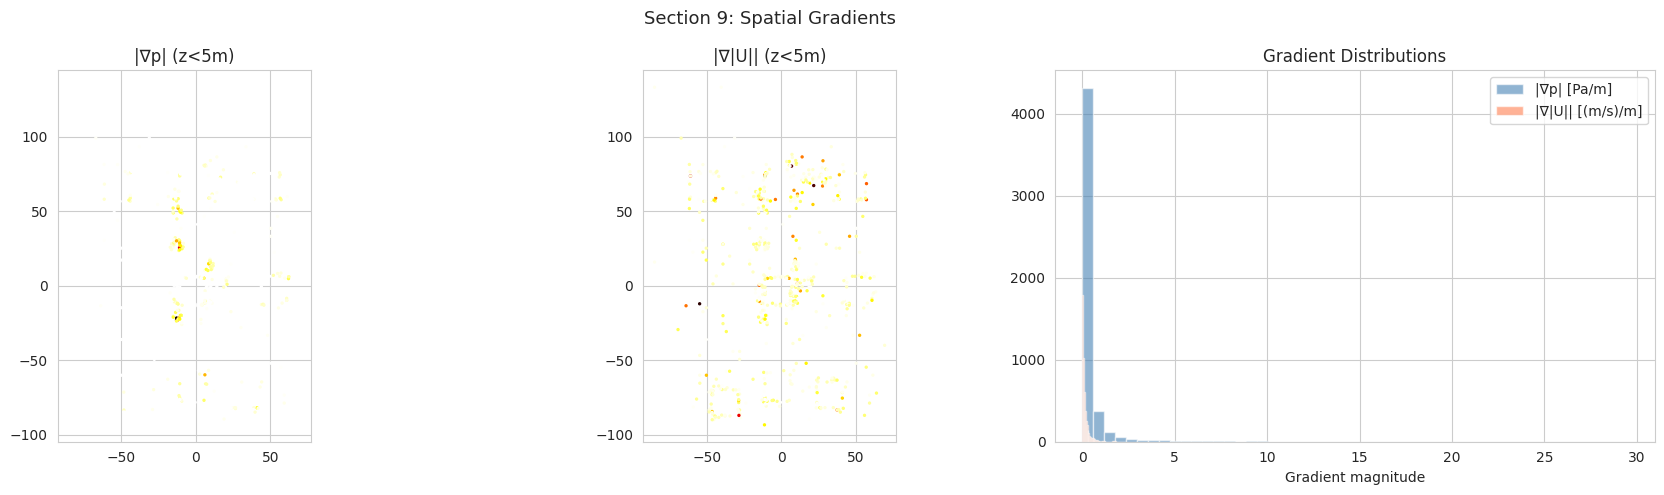

Saved: S9_gradients.png


In [13]:
# ═════════════════════════════════════════════════════════════════════════════
# SECTION 9: SPATIAL SMOOTHNESS & GRADIENT ANALYSIS
# ═════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("  SECTION 9: SPATIAL SMOOTHNESS & GRADIENT")
print("=" * 70)

from scipy.spatial import cKDTree as _KDT

def estimate_gradients(pts, field, k=8, max_sample=5000):
    """Estimate |∇field| at each point using k-NN finite differences."""
    N = len(pts)
    sample_idx = np.random.choice(N, min(max_sample, N), replace=False)
    pts_s  = pts[sample_idx]; f_s = field[sample_idx]
    tree   = _KDT(pts)
    _, idx = tree.query(pts_s, k=k+1)
    grads  = []
    for i in range(len(pts_s)):
        nbrs = idx[i, 1:]   # exclude self
        df   = field[nbrs] - f_s[i]
        dp   = pts[nbrs] - pts_s[i]
        dist = np.linalg.norm(dp, axis=1, keepdims=True).clip(min=0.01)
        grad_mag = np.abs(df / dist[:,0]).mean()
        grads.append(grad_mag)
    return np.array(grads), sample_idx

c0  = cases[0]
pts = c0['cell_centers']; p_g = c0['p_gauge']; U = c0['U']
Umag = np.linalg.norm(U, axis=1)

print(f"\nComputing gradients for {c0['case_name']}...")
grad_p, s_idx = estimate_gradients(pts, p_g)
grad_u, _     = estimate_gradients(pts, Umag)

print(f"  |∇p|  mean={grad_p.mean():.4f}  std={grad_p.std():.4f}  max={grad_p.max():.4f} Pa/m")
print(f"  |∇|U|| mean={grad_u.mean():.4f}  std={grad_u.std():.4f}  max={grad_u.max():.4f} (m/s)/m")

# High-gradient regions
high_grad_p = s_idx[grad_p > np.percentile(grad_p, 90)]
high_grad_u = s_idx[grad_u > np.percentile(grad_u, 90)]
print(f"\n  High ∇p region (top 10%): {len(high_grad_p)} cells")
print(f"    centroid: x={pts[high_grad_p,0].mean():.1f}  y={pts[high_grad_p,1].mean():.1f}  z={pts[high_grad_p,2].mean():.1f}")
print(f"  High ∇|U| region (top 10%): {len(high_grad_u)} cells")

# Uz ≈ 0 check with gradient
grad_uz, _ = estimate_gradients(pts, U[:,2])
print(f"\n  |∇Uz| mean={grad_uz.mean():.4f} — {'Uz is flat (2D-like)' if grad_uz.mean() < 0.01 else 'Uz has 3D structure'}")

# Smoothness check per case (all cases)
print(f"\n📊 Smoothness check (all cases):")
for c in cases[:8]:
    p_g_c = c['p_gauge']; pts_c = c['cell_centers']
    g_p, _ = estimate_gradients(pts_c, p_g_c, max_sample=2000)
    g_u, _ = estimate_gradients(pts_c, np.linalg.norm(c['U'],axis=1), max_sample=2000)
    print(f"  {c['case_name']:<30}  |∇p|_mean={g_p.mean():.3f} Pa/m  |∇U|_mean={g_u.mean():.3f} (m/s)/m")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Section 9: Spatial Gradients', fontsize=13)

mask_z = pts[s_idx, 2] < 5
axes[0].scatter(pts[s_idx[mask_z],0], pts[s_idx[mask_z],1], c=grad_p[mask_z], cmap='hot_r', s=2)
axes[0].set_title('|∇p| (z<5m)'); axes[0].set_aspect('equal')

axes[1].scatter(pts[s_idx[mask_z],0], pts[s_idx[mask_z],1], c=grad_u[mask_z], cmap='hot_r', s=2)
axes[1].set_title('|∇|U|| (z<5m)'); axes[1].set_aspect('equal')

axes[2].hist(grad_p, bins=50, alpha=0.6, label='|∇p| [Pa/m]', color='steelblue')
axes[2].hist(grad_u, bins=50, alpha=0.6, label='|∇|U|| [(m/s)/m]', color='coral')
axes[2].set_xlabel('Gradient magnitude'); axes[2].set_title('Gradient Distributions'); axes[2].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'S9_gradients.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: S9_gradients.png")


In [14]:
# ═════════════════════════════════════════════════════════════════════════════
# SECTION 10: GEOMETRY ANALYSIS & OBJ FILES
# ═════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("  SECTION 10: GEOMETRY ANALYSIS")
print("=" * 70)

# Building footprint from boundary cells
print("\n📐 Building Geometry (from boundary cells):")
for c in cases[:10]:
    bnd = c['boundary_cells']; pts = c['cell_centers']
    if 'buildings' not in bnd or len(bnd['buildings']) == 0:
        print(f"  {c['case_name']}: no building cells")
        continue
    bld_idx = [i for i in bnd['buildings'] if i < c['n_cells']]
    if not bld_idx: continue
    bld_pts = pts[bld_idx]
    x_range = bld_pts[:,0].max() - bld_pts[:,0].min()
    y_range = bld_pts[:,1].max() - bld_pts[:,1].min()
    z_range = bld_pts[:,2].max() - bld_pts[:,2].min()
    bld_cen = bld_pts.mean(axis=0)
    print(f"  {c['case_name']:<30}  Width={x_range:.1f}m  Depth={y_range:.1f}m  Height={z_range:.1f}m  Center=({bld_cen[0]:.0f},{bld_cen[1]:.0f})")

# Inlet area
print("\n📐 Inlet BC Geometry:")
for c in cases[:5]:
    bnd = c['boundary_cells']; pts = c['cell_centers']
    if 'inlet' not in bnd: continue
    in_idx = [i for i in bnd['inlet'] if i < c['n_cells']]
    if not in_idx: continue
    in_pts = pts[in_idx]
    print(f"  {c['case_name']:<30}  inlet n_cells={len(in_idx):>5}  "
          f"x=[{in_pts[:,0].min():.0f},{in_pts[:,0].max():.0f}]  "
          f"y=[{in_pts[:,1].min():.0f},{in_pts[:,1].max():.0f}]  "
          f"z=[{in_pts[:,2].min():.1f},{in_pts[:,2].max():.1f}]")

# Patch type summary
print("\n📋 Patch Types Summary (first case):")
for name, patch in cases[0]['patches'].items():
    print(f"  {name:<20}  type={patch['type']:<20}  nFaces={patch['nFaces']:>8}")


  SECTION 10: GEOMETRY ANALYSIS

📐 Building Geometry (from boundary cells):
  building2: no building cells
  building3                       Width=292.3m  Depth=284.4m  Height=36.2m  Center=(-5,-6)
  building4                       Width=37.4m  Depth=39.3m  Height=60.3m  Center=(-3,0)
  building5                       Width=92.3m  Depth=89.9m  Height=15.1m  Center=(1,4)
  building2: no building cells
  building3                       Width=292.3m  Depth=284.4m  Height=36.2m  Center=(-5,-6)
  building4                       Width=37.4m  Depth=39.3m  Height=60.3m  Center=(-3,0)
  building5                       Width=92.3m  Depth=89.9m  Height=15.1m  Center=(1,4)
  building2: no building cells
  building3                       Width=292.3m  Depth=284.4m  Height=36.2m  Center=(-5,-6)

📐 Inlet BC Geometry:
  building2                       inlet n_cells=  600  x=[-130,-130]  y=[-155,155]  z=[3.0,117.0]
  building3                       inlet n_cells=  600  x=[-367,-367]  y=[-353,353]  z=[1

In [16]:
# ═════════════════════════════════════════════════════════════════════════════
# BONUS: Per-Case Complete Summary Table
# ═════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 120)
print("  PER-CASE COMPLETE SUMMARY")
print("=" * 120)
header = (f"{'Case':<30} {'Loc':<15} {'Cells':>8} {'t':>5} "
          f"{'|Ui|':>6} {'Angle°':>7} "
          f"{'p_mean':>8} {'p_std':>8} {'p_min':>8} {'p_max':>8} "
          f"{'|U|_mean':>9} {'|U|_max':>9}")
print(header); print("-" * 120)
for c in cases:
    ui  = c['Uinlet']; spd = float(np.linalg.norm(ui))
    ang = float(np.degrees(np.arctan2(ui[1], ui[0])) % 360)
    pg  = c['p_gauge']; umag = np.linalg.norm(c['U'], axis=1)
    print(f"{c['case_name']:<30} {c['location']:<15} {c['n_cells']:>8,} {c['timestep']:>5} "
          f"{spd:>6.2f} {ang:>7.1f} "
          f"{pg.mean():>8.2f} {pg.std():>8.2f} {pg.min():>8.2f} {pg.max():>8.2f} "
          f"{umag.mean():>9.3f} {umag.max():>9.3f}")

print("=" * 120)
print(f"TOTAL: {len(cases)} cases  |  "
      f"Cells: {min(c['n_cells'] for c in cases):,}–{max(c['n_cells'] for c in cases):,}  |  "
      f"Angles: {len(set(round(float(np.degrees(np.arctan2(c['Uinlet'][1],c['Uinlet'][0]))%360)/15)*15 for c in cases))} unique")



  PER-CASE COMPLETE SUMMARY
Case                           Loc                Cells     t   |Ui|  Angle°   p_mean    p_std    p_min    p_max  |U|_mean   |U|_max
------------------------------------------------------------------------------------------------------------------------
building2                      dublin_Spring    373,609  4000   4.38   135.0    -7.48     2.41   -29.00    19.00     1.941     5.822
building3                      dublin_Spring    246,393  4000   4.38   135.0    -9.03     2.83   -25.00     5.00     1.837     5.259
building4                      dublin_Spring    204,531  4000   4.38   135.0    -7.49     3.35   -43.00    29.00     1.924     6.735
building5                      dublin_Spring    306,217  4000   4.38   135.0    -8.07     3.23   -50.00    28.00     2.081     6.942
building2                      dublin_Summer    373,609  4000   4.30   180.0   -14.19     4.20   -53.00     9.00     2.679     7.541
building3                      dublin_Summer    246,